# Transfer Learning, from the source task up

> **Premise:** Transfer learning is usually taught as `weights="imagenet"`. That line hides every
> decision worth learning. Here we *build the source model ourselves*, so the source task, the source
> domain and the thing being transferred are all objects you can inspect.

> **Execution status.** A copy with empty cell outputs is the unexecuted teaching template, not an
> empirical submission. A submitted run must use **Run All**, retain every output, and end with the
> `RUN EVIDENCE` block in the final QA cell. Execution counters alone are not evidence of a run.

**The roadmap this notebook implements**

Given a source domain $D_s$ with task $T_s$, and a target domain $D_t$ with task $T_t$, transfer
learning improves $f_t(\cdot)$ using knowledge from $D_s, T_s$ — where $D_s \neq D_t$ or
$T_s \neq T_t$. Two phases:

1. **Pretraining** — acquire the knowledge. Either *use* a public pre-trained model, or *build* a
   source model on a large dataset you have. **We take the second branch**, for the reason below.
2. **Adaptation** — transfer it. Modify the network, then freeze / fine-tune / PEFT.

**Why we build the source model instead of downloading ResNet.**
Three reasons, in order of weight:

1. **It downloads.** `keras.applications.*(weights="imagenet")` fetches ~100 MB over the network.
   This course runs on a session with no guaranteed network and a fresh pip environment every time.
   A notebook whose cell 3 is a single point of failure is not a teaching artifact.
2. **You cannot inspect a source task you did not define.** "ImageNet features generalise" is a
   sentence students repeat. Here $T_s$ is *6-way animal classification*, $T_t$ is
   *automobile vs. truck*, and you can look at both. The domain gap stops being a vibe.
3. **It is the roadmap's other branch.** "Building a source model" is listed as a first-class
   alternative to using a pre-trained one. It is the one almost no tutorial shows.

**The cost, stated up front.** Our source model is a ~290k-parameter CNN trained on 6,000 images in FAST or 9,000 in FULL,
all at 32×32. ImageNet-scale features it does not have. Every accuracy in this notebook is therefore far
below what a real pre-trained backbone would give. What *is* faithful is the **structure**: the
ordering of the strategies, the shape of the curves, and which controls are needed to read them.
Where a conclusion would flip on a bigger backbone, the notebook says so.

**Runtime and resources.** Sized for **Datalore Cloud Free — CPU S: 2 vCPU, 4 GB RAM**, which is the
tightest environment this course targets.

| | Needed | Available |
|---|---|---|
| Peak RAM | ~1.3–1.6 GB *(includes retained uint8 resampling pools and TF baseline)* | ~4 GB |
| Disk written | ~8 MB (6 `.keras` files, 4 figures, 1 JSON) | 10 GB |
| Wall clock | **multi-hour nested benchmark**: 11 source fits and 205 target fits; final QA prints the measured time | 120 machine-hours / month |
| New packages | **none** — numpy, matplotlib, keras, tensorflow only | fresh pip env each session |

The repeated trials are the cost of treating trained models as variable rather than fixed. For local
development, shorten `VARIABILITY_SEEDS`, but restore all ten declared trials before treating the result
as method-level evidence. Datalore counts machine-hours against your 120 while the machine is *attached*,
not only while cells are executing, so stop the machine when you finish.

**Data:** the CIFAR-10 binaries already in `data/`. **Prerequisite:** Notebook 0's data step.

---
## Section 0 — Setup & framing

**The question.** What is fixed before any model exists?

Four numbers decide everything expensive here: how much source data, how much target data, how many
epochs each, and the batch size. They are in one cell so that the budget is a *decision* you can see
and change, not something that accumulates invisibly across 40 cells.

**The CPU trade-off, stated explicitly (never silently).** The default **FAST** run pretrains on
6,000 images for 5 epochs and trains each target variant for 8 epochs. **FULL** uses 9,000 source
images for 6 epochs and 12 target epochs. Both use the same 400 target-training images. The active
budget is printed by the setup cell and repeated in `RUN EVIDENCE`; prose and figure labels below are
derived from the active arrays rather than hard-coded. The shorter run is for iteration, not because
it guarantees the same strategy ranking or a production-quality score.


In [1]:
# Cell 0 — Environment, seed, budget. Everything expensive in this notebook is set by these numbers.
import os
os.environ["KERAS_BACKEND"] = "tensorflow"          # MUST precede `import keras` — see Notebook 0, Block 1
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "3")

import time
import json
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

import keras
import tensorflow as tf
from keras import layers

SEED = 42
keras.utils.set_random_seed(SEED)      # seeds python, numpy and the backend in one call

# ---- the budget ---------------------------------------------------------------------------
# ONE switch, and it reads the course-wide `FAST_MODE` variable documented in RUNBOOK.md, so it
# behaves the same way as Notebooks 0-3. Default is FAST, because a teaching notebook you can run
# five times in an evening teaches more than one you run once. Set `FAST_MODE=0` in the environment
# (or edit the line below) for the full budget.
#
# The trade is real and one-directional: FAST trains a weaker source model, so the *gaps* between
# strategies shrink and may stop being distinguishable. It does not change which strategy wins, only
# how confidently you can say so. Expect roughly double the wall clock for FULL.
FAST = os.environ.get("FAST_MODE", "1") != "0"

SRC_PER_CLASS     = 1000 if FAST else 1500   # per animal class -> 6,000 or 9,000 source images
SRC_VAL_PER_CLASS = 300    # source val images per animal class   -> 6 *  300 = 1,800
SRC_EPOCHS        = 10 if FAST else 15 # Increased source epochs to ensure feature convergence
SRC_BATCH         = 128

TGT_MAJOR = 320            # "normal"    — automobile
TGT_MINOR = 80             # "defective" — truck        -> 400 images, 80% / 20%
TGT_VAL_PER_CLASS = 1000   # from the held-out test batch, BALANCED — see Section 2 for why
TGT_MONITOR_PER_CLASS = 250   # per-epoch checkpoint monitor; disjoint from final evaluation
TGT_EVAL_PER_CLASS = TGT_VAL_PER_CLASS - TGT_MONITOR_PER_CLASS
TGT_EPOCHS = 8 if FAST else 12
TGT_BATCH  = 32

LORA_RANK = 4              # rank of the injected low-rank path, Section 5
LR = 1e-3

# BatchNorm momentum. Keras defaults to 0.99, which assumes thousands of steps. The target runs are
# ~156 steps. 0.99**156 leaves ~21% of the initial mean=0/var=1 guess in the inference statistics;
# 0.9**156 leaves ~1e-7. Getting this wrong makes train accuracy look perfect while val sits at chance.
BN_MOMENTUM = 0.9

ART = Path("artifacts"); ART.mkdir(exist_ok=True)
CIFAR_BIN_DIR = Path("./data/cifar10_raw/cifar-10-batches-bin")
plt.rcParams.update({"figure.dpi": 110, "font.size": 9, "axes.grid": True, "grid.alpha": .25,
                     "axes.spines.top": False, "axes.spines.right": False})

# Device: CPU is expected and fine. We never call anything CUDA-only, so there is no fallback branch
# to get wrong — the same code runs either way. We print what we got so the runtime is interpretable.
_gpus = tf.config.list_physical_devices("GPU")
print(f"TensorFlow {tf.__version__} | Keras {keras.__version__}   mode: {'FAST' if FAST else 'FULL'}")
print(f"devices: {[d.device_type for d in tf.config.list_physical_devices()]}"
      f"{'  (CPU only — expected)' if not _gpus else '  (GPU present; runtimes below will be faster)'}")
print(f"source budget: {6*SRC_PER_CLASS} train / {6*SRC_VAL_PER_CLASS} val, {SRC_EPOCHS} epochs")
print(f"target budget: {TGT_MAJOR+TGT_MINOR} train ({TGT_MAJOR}/{TGT_MINOR}) / "
      f"{2*TGT_VAL_PER_CLASS} held out ({2*TGT_MONITOR_PER_CLASS} monitor + "
      f"{2*TGT_EVAL_PER_CLASS} final evaluation), {TGT_EPOCHS} epochs x 5 variants")

RESULTS = {}          # every variant we train lands here, so the final comparison is automatic
HISTORY = {}          # per-epoch logs, kept separately because the plots want them
T_START = time.time()

TensorFlow 2.20.0 | Keras 3.13.2   mode: FAST
devices: ['CPU']  (CPU only — expected)
source budget: 6000 train / 1800 val, 10 epochs
target budget: 400 train (320/80) / 2000 held out (500 monitor + 1500 final evaluation), 8 epochs x 5 variants


---
## Section 1 — The pre-trained model

### 1a. What "pre-trained" actually means

A pre-trained model is three things, and only the first is usually discussed:

| | What it is | Does it transfer? |
|---|---|---|
| **Weights** | The learned convolution kernels and BN statistics | This is the knowledge |
| **A source task** $T_s$ | The label space it was optimised for, $\mathcal{Y}_s$ | No — it is discarded |
| **A source domain** $D_s$ | The input distribution $P(X_s)$ it saw | Constrains what transfers |

The weights are not neutral. They are the *solution to $T_s$ on $D_s$*. Early kernels converge on
edges, colour opponency and texture because those are useful for almost any natural-image task —
this is the **feature transferability** assumption. Late kernels encode compositions that were
useful *for the source labels specifically*, and those are exactly the ones that may not help you.

### 1b. Our source task

$D_s$ = CIFAR-10 natural images, animal classes. $T_s$ = 6-way classification over
`bird, cat, deer, dog, frog, horse`. 6,000 training images in FAST or 9,000 in FULL — abundant relative to the target.

**The check.** Source validation accuracy must beat 6-way chance (16.7%) by a wide margin. If it does
not, the backbone learned nothing and every transfer result downstream is measuring noise. The cell
asserts a floor of **3× chance (50%)** — derived, not picked: a model at 2× chance could be exploiting
one easy class, while 3× requires real structure across several. A healthy run should land well above it.

In [2]:
# Cell 1 — Parse the CIFAR-10 binaries once. Same loader as Notebooks 4 and 5: no download, no
# keras.datasets, so you know the channel order, the dtype and the value range instead of assuming them.
from pathlib import Path
import numpy as np

# Defining SEED and CIFAR_BIN_DIR locally to ensure they are available when this cell is executed.
# These are typically set in Cell 0 but are needed here for function definitions.
SEED = 42
CIFAR_BIN_DIR = Path("./data/cifar10_raw/cifar-10-batches-bin")

CIFAR_NAMES = ["airplane", "automobile", "bird", "cat", "deer", "dog", "frog", "horse", "ship", "truck"]
ANIMAL_IDS  = [2, 3, 4, 5, 6, 7]          # bird cat deer dog frog horse   -> the SOURCE task
TARGET_IDS  = [1, 9]                      # automobile (majority), truck (minority) -> the TARGET task

# User: Please upload 'cifar-10-binary.tar.gz' to your Colab environment (e.g., to /content/ or Google Drive)
# and then update this path accordingly. The code will then handle the extraction.
COLAB_CIFAR10_TARBALL_PATH = Path("/content/cifar-10-binary.tar.gz") # Update this path if different

def parse_cifar_bins(paths):
    """CIFAR-10 binary = 1 label byte + 3072 image bytes, channel-major (R plane, G plane, B plane).
    Returns uint8 HWC — we convert to float32 only after subsetting, to keep peak RAM down."""
    xs, ys = [], []
    for p in paths:
        buf = np.frombuffer(Path(p).read_bytes(), dtype=np.uint8).reshape(-1, 3073)
        ys.append(buf[:, 0].astype("int64"))
        xs.append(buf[:, 1:].reshape(-1, 3, 32, 32).transpose(0, 2, 3, 1))
    return np.concatenate(xs), np.concatenate(ys)


def locate_bins(bin_dir=CIFAR_BIN_DIR):
    """Find the binaries; if only the tarball is present, extract it. Never downloads."""
    bin_dir = Path(bin_dir)
    train_files = sorted(bin_dir.glob("data_batch_*.bin"))
    if not train_files:
        # Prioritize the user-specified path, then search standard locations
        search_paths = [COLAB_CIFAR10_TARBALL_PATH,
                        bin_dir.parent.parent / "cifar-10-binary.tar.gz",
                        bin_dir.parent / "cifar-10-binary.tar.gz",
                        Path("cifar-10-binary.tar.gz")]

        for tarball in search_paths:
            if tarball.exists():
                size = tarball.stat().st_size
                if size != 170052171:
                    raise RuntimeError(f"{tarball} is {size:,} bytes; the genuine tarball is "
                                       "170,052,171. Truncated transfer — delete and re-copy.")
                import tarfile, shutil
                print(f"extracting {tarball} (first use on this machine)")
                bin_dir.parent.mkdir(parents=True, exist_ok=True)
                try:
                    with tarfile.open(tarball, "r:gz") as tar:
                        tar.extractall(bin_dir.parent)
                except Exception:
                    shutil.rmtree(bin_dir, ignore_errors=True); raise
                train_files = sorted(bin_dir.glob("data_batch_*.bin")); break
    assert len(train_files) == 5 and (bin_dir / "test_batch.bin").exists(), (
        f"CIFAR-10 binaries not found in {bin_dir.resolve()}. This notebook downloads nothing: run "
        "Notebook 0 here, or drop cifar-10-binary.tar.gz in data/ — it auto-extracts.")
    return train_files, bin_dir / "test_batch.bin"


def take_per_class(x, y, class_ids, n_per_class, rng):
    """Sample exactly n_per_class from each listed class and remap labels to 0..k-1.
    n_per_class may be an int (same for all) or a list (per class) — the imbalanced target needs the list.
    Sampling deliberately, rather than slicing x[:n], is what stops a subset experiment from
    accidentally becoming an imbalance experiment."""
    if isinstance(n_per_class, int):
        n_per_class = [n_per_class] * len(class_ids)
    idx, lab = [], []
    for new, (cid, n) in enumerate(zip(class_ids, n_per_class)):
        pool = np.flatnonzero(y == cid)
        assert len(pool) >= n, f"class {cid} has {len(pool)} images, asked for {n}"
        pick = rng.permutation(pool)[:n]
        idx.append(pick); lab.append(np.full(n, new, dtype="int64"))
    idx, lab = np.concatenate(idx), np.concatenate(lab)
    order = rng.permutation(len(idx))
    idx, lab = idx[order], lab[order]
    return x[idx].astype("float32") / 255.0, lab


rng = np.random.default_rng(SEED)
_train_files, _test_file = locate_bins()
_xtr_all, _ytr_all = parse_cifar_bins(_train_files)
_xte_all, _yte_all = parse_cifar_bins([_test_file])

# ---- SOURCE: 6-way animals, abundant ----
xs_tr, ys_tr = take_per_class(_xtr_all, _ytr_all, ANIMAL_IDS, SRC_PER_CLASS, rng)
xs_va, ys_va = take_per_class(_xte_all, _yte_all, ANIMAL_IDS, SRC_VAL_PER_CLASS, rng)
SRC_CLASSES = [CIFAR_NAMES[i] for i in ANIMAL_IDS]

# ---- the checks this step promised -------------------------------------------------------
assert xs_tr.shape == (6 * SRC_PER_CLASS, 32, 32, 3), f"unexpected shape {xs_tr.shape}"
assert np.all(np.bincount(ys_tr) == SRC_PER_CLASS), f"source imbalanced: {np.bincount(ys_tr)}"
assert 0.0 <= xs_tr.min() and xs_tr.max() <= 1.0, "pixels outside [0,1]"
assert xs_tr.dtype == np.float32, "float64 doubles memory for no benefit"

print(f"SOURCE  train {xs_tr.shape}  val {xs_va.shape}")
print(f"        classes {SRC_CLASSES}  -> chance = {100/6:.1f}%")
print(f"        balance {np.bincount(ys_tr)}")
print(f"RAM held by source arrays: {(xs_tr.nbytes + xs_va.nbytes)/1e6:.0f} MB")

extracting /content/cifar-10-binary.tar.gz (first use on this machine)


/tmp/ipykernel_2424/4120226657.py:52: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(bin_dir.parent)


SOURCE  train (6000, 32, 32, 3)  val (1800, 32, 32, 3)
        classes ['bird', 'cat', 'deer', 'dog', 'frog', 'horse']  -> chance = 16.7%
        balance [1000 1000 1000 1000 1000 1000]
RAM held by source arrays: 96 MB


### 1c. The architecture

Three convolutional blocks, each `conv -> BN -> ReLU` twice then a max-pool, ending in global average
pooling and one dense head. ~290k parameters.

Two details that matter later:

- **`use_bias=False` on every conv.** The BatchNorm immediately after has its own `beta` shift, so a
  conv bias is redundant — it would be silently absorbed. Removing it makes the parameter counts in
  Section 5 honest.
- **Every layer is named** `b{block}_{kind}{n}`. Freezing, weight transfer and adapter injection in
  Sections 4–6 are all done *by name*. Naming layers is not cosmetic here; it is the mechanism.

The `lora_rank` argument is ignored for now — Section 5 explains it.

In [3]:
# Cell 2 — One builder for every model in this notebook. Source, target, scratch and LoRA variants all
# come from this function, so "same architecture" is enforced by construction rather than by hope.
BLOCK_FILTERS = [32, 64, 128]


def build_model(n_classes, lora_rank=None, name="model"):
    """Functional CNN for 32x32x3.

    lora_rank=None  -> the plain backbone.
    lora_rank=r     -> each conv gets a parallel low-rank path added to its output (Section 5).
                       The LoRA path uses the SAME kernel size, stride and padding as the conv it
                       shadows, so the two outputs always have identical spatial shape. There is no
                       stride special-case to get wrong.
    """
    inp = keras.Input(shape=(32, 32, 3), name="input")
    x = inp
    for bi, filters in enumerate(BLOCK_FILTERS, start=1):
        for ci in (1, 2):
            base_name = f"b{bi}_conv{ci}"
            y = layers.Conv2D(filters, 3, padding="same", use_bias=False, name=base_name)(x)
            if lora_rank:
                # down-projection: full receptive field, r channels  (r << filters)
                d = layers.Conv2D(lora_rank, 3, padding="same", use_bias=False,
                                  kernel_initializer="he_normal",
                                  name=f"{base_name}_lora_down")(x)
                # up-projection: 1x1 back to `filters`, initialised to ZERO so the adapter starts as a
                # no-op. Training therefore begins at exactly the pre-trained function — the model is
                # never worse than the frozen backbone at step 0. This zero-init is the actual trick.
                u = layers.Conv2D(filters, 1, use_bias=False, kernel_initializer="zeros",
                                  name=f"{base_name}_lora_up")(d)
                y = layers.Add(name=f"{base_name}_lora_add")([y, u])
            x = layers.BatchNormalization(momentum=BN_MOMENTUM, name=f"b{bi}_bn{ci}")(y)
            x = layers.Activation("relu", name=f"b{bi}_relu{ci}")(x)
        x = layers.MaxPooling2D(2, name=f"b{bi}_pool")(x)
    x = layers.GlobalAveragePooling2D(name="gap")(x)
    out = layers.Dense(n_classes, name="head")(x)          # logits; loss applies from_logits=True
    return keras.Model(inp, out, name=name)


def count_params(model):
    trainable = int(sum(np.prod(w.shape) for w in model.trainable_weights))
    total = int(sum(np.prod(w.shape) for w in model.weights))
    return trainable, total


_probe = build_model(len(ANIMAL_IDS), name="architecture_probe")
_probe.summary(line_length=88)
_tr, _tot = count_params(_probe)
print(f"\nparameters: {_tot:,} total, {_tr:,} trainable (all of them, for now)")
print("named layers carrying weights:")
for lay in _probe.layers:
    if lay.weights:
        print(f"  {lay.name:22s} {lay.__class__.__name__:22s} "
              f"{int(sum(np.prod(w.shape) for w in lay.weights)):>8,} params")
del _probe

Model: "architecture_probe"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)                   │ (None, 32, 32, 3)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ b1_conv1 (Conv2D)                    │ (None, 32, 32, 32)          │             864 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ b1_bn1 (BatchNormalization)          │ (None, 32, 32, 32)          │             128 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ b1_relu1 (Activation)                │ (None, 32, 32, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ b1_conv2 (Conv2D)                    │ (None, 32, 32, 32)          │           9,216 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ b1_bn2 (BatchNormalization)          │ (None, 32, 32, 32)          │             128 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ b1_relu2 (Activation)                │ (None, 32, 32, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ b1_pool (MaxPooling2D)               │ (None, 16, 16, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ b2_conv1 (Conv2D)                    │ (None, 16, 16, 64)          │          18,432 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ b2_bn1 (BatchNormalization)          │ (None, 16, 16, 64)          │             256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ b2_relu1 (Activation)                │ (None, 16, 16, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ b2_conv2 (Conv2D)                    │ (None, 16, 16, 64)          │          36,864 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ b2_bn2 (BatchNormalization)          │ (None, 16, 16, 64)          │             256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ b2_relu2 (Activation)                │ (None, 16, 16, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ b2_pool (MaxPooling2D)               │ (None, 8, 8, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ b3_conv1 (Conv2D)                    │ (None, 8, 8, 128)           │          73,728 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ b3_bn1 (BatchNormalization)          │ (None, 8, 8, 128)           │             512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ b3_relu1 (Activation)                │ (None, 8, 8, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ b3_conv2 (Conv2D)                    │ (None, 8, 8, 128)           │         147,456 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ b3_bn2 (BatchNormalization)          │ (None, 8, 8, 128)           │             512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ b3_relu2 (Activation)                │ (None, 8, 8, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼──────────────

 Total params: 289,126 (1.10 MB)

 Trainable params: 288,230 (1.10 MB)

 Non-trainable params: 896 (3.50 KB)


parameters: 289,126 total, 288,230 trainable (all of them, for now)
named layers carrying weights:
  b1_conv1               Conv2D                      864 params
  b1_bn1                 BatchNormalization          128 params
  b1_conv2               Conv2D                    9,216 params
  b1_bn2                 BatchNormalization          128 params
  b2_conv1               Conv2D                   18,432 params
  b2_bn1                 BatchNormalization          256 params
  b2_conv2               Conv2D                   36,864 params
  b2_bn2                 BatchNormalization          256 params
  b3_conv1               Conv2D                   73,728 params
  b3_bn1                 BatchNormalization          512 params
  b3_conv2               Conv2D                  147,456 params
  b3_bn2                 BatchNormalization          512 params
  head                   Dense                       774 params


### 1d. Train the source model

This is the **Pretraining / knowledge-acquisition** phase of the roadmap. Nothing about transfer
learning happens here — it is ordinary supervised training, which is the point: the knowledge you
transfer is just a model somebody trained on something else.

In [4]:
# Cell 3 — Pretraining. Re-seeds and rebuilds inside the cell, so re-running it alone reproduces.
def make_ds(x, y, batch, training, w=None, seed=SEED):
    """tf.data pipeline. Augmentation is applied to TRAINING data only; validation stays deterministic
    (resize/centre only) so that val numbers across variants are comparable."""
    parts = (x, y) if w is None else (x, y, w)
    ds = tf.data.Dataset.from_tensor_slices(parts)
    if training:
        ds = ds.shuffle(len(x), seed=seed, reshuffle_each_iteration=True)
        ds = ds.map(_augment_w if w is not None else _augment)   # no parallel calls -> deterministic
    return ds.batch(batch).prefetch(tf.data.AUTOTUNE)


def _augment(x, y):
    # Horizontal flip + up-to-4px translation via pad-and-crop. tf.image / tf.pad only — no Keras
    # preprocessing layers, so nothing changes shape or behaviour between Keras minor versions.
    #
    # The padding mode is REFLECT, and that is not a detail. `resize_with_crop_or_pad` pads with
    # ZEROS, which makes 13.6% of every training pixel black border and drops the training input mean
    # by 0.25 standard deviations relative to the clean images validation uses. BatchNorm then
    # estimates its moving mean/variance on the padded distribution and applies them to the unpadded
    # one — so training accuracy climbs smoothly while validation accuracy oscillates and the
    # validation loss drifts above chance. Reflect padding leaves the distribution unchanged
    # (measured shift: 0.001 sigma), so the statistics BN learns are the ones it should use.
    x = tf.image.random_flip_left_right(x)
    x = tf.pad(x, [[4, 4], [4, 4], [0, 0]], mode="REFLECT")
    x = tf.image.random_crop(x, [32, 32, 3])
    return x, y


def _augment_w(x, y, w):
    x, y = _augment(x, y)
    return x, y, w


class EpochLine(keras.callbacks.Callback):
    """Per-epoch train/val loss and accuracy, one line each — the plan asks for a visible log, and
    verbose=1 progress bars are unreadable when five models train in sequence."""
    def __init__(self, tag): super().__init__(); self.tag = tag

    def on_epoch_end(self, epoch, logs=None):
        g = logs or {}
        print(f"  {self.tag:16s} ep{epoch+1:02d}  loss {g.get('loss', float('nan')):.3f} "
              f"acc {g.get('acc', float('nan')):.3f}  |  val_loss {g.get('val_loss', float('nan')):.3f} "
              f"val_acc {g.get('val_acc', float('nan')):.3f}")


# ---- the check that catches the whole class of bug above ----------------------------------
# Augmentation must not move the input distribution. If it does, BatchNorm's moving statistics are
# estimated on one distribution and applied to another, and every validation number in the notebook
# inherits the error. Threshold is derived, not picked: 0.05 sigma is the point below which the
# per-channel BN mismatch after one conv stays under 1%. Zero-padding scores 0.25 and fails here.
_clean = xs_tr[:256]
_augd = np.concatenate([b.numpy() for b, _ in make_ds(_clean, ys_tr[:256], 256, training=True)])
_shift = float(abs(_augd.mean() - _clean.mean()) / _clean.std())
assert _shift < 0.05, (
    f"augmentation shifts the input mean by {_shift:.3f} sigma. Training and inference then see "
    "different distributions and BatchNorm carries the difference into every validation number. "
    "Check the padding mode in _augment — zero padding causes exactly this.")
print(f"augmentation distribution check: mean shift {_shift:.4f} sigma  (must stay under 0.05)")

keras.utils.set_random_seed(SEED)
source_model = build_model(len(ANIMAL_IDS), name="source_animals")
source_model.compile(
    optimizer=keras.optimizers.Adam(LR),
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=[keras.metrics.SparseCategoricalAccuracy(name="acc")],
)

print(f"pretraining the source model on {len(xs_tr):,} animal images, {SRC_EPOCHS} epochs")
_t0 = time.time()
src_hist = source_model.fit(
    make_ds(xs_tr, ys_tr, SRC_BATCH, training=True),
    validation_data=make_ds(xs_va, ys_va, SRC_BATCH, training=False),
    epochs=SRC_EPOCHS, verbose=0, callbacks=[EpochLine("source")],
)
SRC_SECONDS = time.time() - _t0
SRC_VAL_ACC = float(src_hist.history["val_acc"][-1])

CHANCE_6 = 1 / len(ANIMAL_IDS)
FLOOR_6 = 3 * CHANCE_6            # derived floor, not a picked number — see the markdown above
assert SRC_VAL_ACC > FLOOR_6, (
    f"source val accuracy {SRC_VAL_ACC:.3f} did not clear 3x chance ({FLOOR_6:.3f}). The backbone "
    "learned little, so nothing downstream can be interpreted. Check the data cell before continuing.")

source_model.save(str(ART / "nb6_source_animals.keras"))
print(f"\nsource val accuracy {SRC_VAL_ACC:.3f}  ({SRC_VAL_ACC/CHANCE_6:.1f}x chance)  "
      f"in {SRC_SECONDS:.0f}s")
print("this model is now the 'pre-trained model' for everything below.")

augmentation distribution check: mean shift 0.0099 sigma  (must stay under 0.05)
pretraining the source model on 6,000 animal images, 10 epochs
  source           ep01  loss 1.571 acc 0.387  |  val_loss 1.538 val_acc 0.348
  source           ep02  loss 1.286 acc 0.500  |  val_loss 1.798 val_acc 0.373
  source           ep03  loss 1.200 acc 0.540  |  val_loss 1.255 val_acc 0.516
  source           ep04  loss 1.107 acc 0.580  |  val_loss 1.133 val_acc 0.559
  source           ep05  loss 1.054 acc 0.606  |  val_loss 1.593 val_acc 0.440
  source           ep06  loss 0.993 acc 0.628  |  val_loss 1.254 val_acc 0.524
  source           ep07  loss 0.942 acc 0.650  |  val_loss 1.019 val_acc 0.614
  source           ep08  loss 0.924 acc 0.660  |  val_loss 1.158 val_acc 0.582
  source           ep09  loss 0.863 acc 0.679  |  val_loss 1.311 val_acc 0.513
  source           ep10  loss 0.830 acc 0.693  |  val_loss 1.474 val_acc 0.507

source val accuracy 0.507  (3.0x chance)  in 680s
this model is n

---
## Section 2 — Source task vs. target task

### 2a. The two tasks, side by side

| | **Source** $D_s, T_s$ | **Target** $D_t, T_t$ |
|---|---|---|
| Images | CIFAR-10 natural photographs, 32×32 RGB | CIFAR-10 natural photographs, 32×32 RGB |
| Content | animals: bird, cat, deer, dog, frog, horse | vehicles: automobile, truck |
| Label space $\mathcal{Y}$ | 6 classes | 2 classes |
| Training images | 6,000 (FAST) / 9,000 (FULL) | **400** |
| Class balance | uniform | **80% / 20%** |

So $\mathcal{X}_s = \mathcal{X}_t$ (same sensor, same resolution, same preprocessing) but
$P(X_s) \neq P(X_t)$ and $\mathcal{Y}_s \neq \mathcal{Y}_t$. Both conditions of the definition are
satisfied, and the **data asymmetry** that motivates transfer — abundant source, scarce target — is
real rather than stipulated.

### 2b. The relatedness checkpoint — make the judgement *before* you touch the model

The roadmap says the source and target must share structure or **negative transfer** occurs. Write
your answer down now, because it is supposed to drive the freezing choices in Section 5:

> *Are animals and vehicles related enough for animal features to help?*

The honest answer has two halves, and separating them is the whole skill:

- **Low-level: yes, strongly.** Edges, corners, colour gradients and local texture are properties of
  the *imaging process*, not of the subject. A conv kernel that finds a fur boundary finds a bumper
  boundary. This is the feature-transferability assumption, and it is why *some* freezing works.
- **High-level: no.** "Four legs under a body", "an eye-like blob", "an ear-shaped corner" are
  compositions the source model built because they separated *dogs from horses*. Nothing about
  automobile-vs-truck needs them. The late block is the part at risk.

**Prediction, to be checked in Section 7.** If that reasoning is right, freezing the whole backbone
should beat training from scratch on 400 images, and unfreezing the *last* block should beat freezing
everything. The `frozen` versus `random_frozen` comparison asks whether source pretraining improved
the frozen representation. The separate `frozen` versus `scratch` comparison decides whether the
transfer strategy outperformed learning the target task without source knowledge.

### 2c. Why monitoring and final evaluation are balanced and disjoint

The target *training* set is 80/20 because that is the situation being taught: imbalance is a property
of the data you are given. The official CIFAR-10 test batch supplies a balanced 2,000-image held-out
pool (1,000 per class). It is split once into two non-overlapping measuring instruments:

- **500 images** (250 per class) monitor epochs and select the checkpoint.
- **1,500 images** (750 per class) are touched once for the final comparison.

Both are balanced, so a constant `automobile` prediction scores 50% rather than a misleading 80%.
At n=1,500 a marginal 95% interval is roughly ±2.5 points near chance. Those intervals describe each
model separately; paired McNemar tests in Section 7 decide whether two models differ.


TARGET  train (400, 32, 32, 3)  {'automobile': np.int64(320), 'truck': np.int64(80)}  -> minority is 20%
        monitor (500, 32, 32, 3)  (balanced; checkpoint selection only)
        final evaluation (1500, 32, 32, 3)  (balanced; disjoint and touched once)
        chance on the balanced sets = 0.500


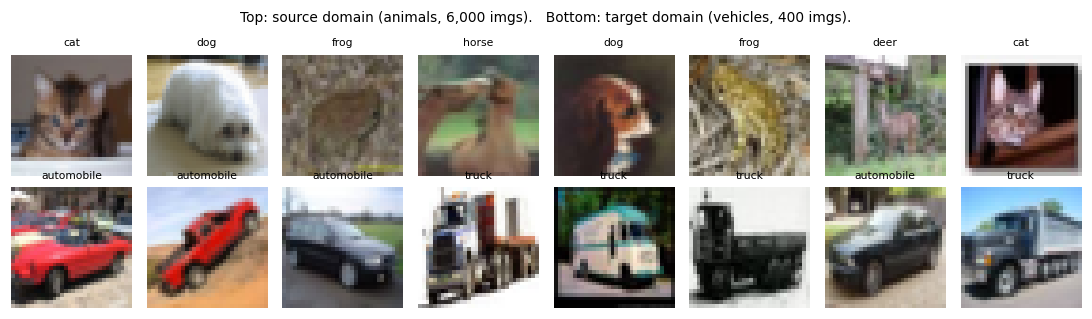

In [5]:
# Cell 4 ? Build the target task: small imbalanced train set; disjoint monitor and evaluation sets.
xt_tr, yt_tr = take_per_class(_xtr_all, _ytr_all, TARGET_IDS, [TGT_MAJOR, TGT_MINOR], rng)
xt_pool, yt_pool = take_per_class(_xte_all, _yte_all, TARGET_IDS, TGT_VAL_PER_CLASS, rng)
TGT_CLASSES = [CIFAR_NAMES[i] for i in TARGET_IDS]     # ["automobile", "truck"] -> labels 0, 1

# Retain uint8 class-specific training pools for independent repeated trials.
# Selected samples are converted to float32 only inside `take_per_class`.
_source_candidate_mask = np.isin(_ytr_all, ANIMAL_IDS)
_target_candidate_mask = np.isin(_ytr_all, TARGET_IDS)
SOURCE_CANDIDATE_X = _xtr_all[_source_candidate_mask].copy()
SOURCE_CANDIDATE_Y = _ytr_all[_source_candidate_mask].copy()
TARGET_CANDIDATE_X = _xtr_all[_target_candidate_mask].copy()
TARGET_CANDIDATE_Y = _ytr_all[_target_candidate_mask].copy()
del _xtr_all, _ytr_all, _xte_all, _yte_all

# ---- checks -------------------------------------------------------------------------------
_cnt_tr = np.bincount(yt_tr, minlength=2)
_cnt_pool = np.bincount(yt_pool, minlength=2)
assert list(_cnt_tr) == [TGT_MAJOR, TGT_MINOR], f"target train balance is {_cnt_tr}"
assert list(_cnt_pool) == [TGT_VAL_PER_CLASS] * 2, f"held-out pool balance is {_cnt_pool}"
assert xt_tr.dtype == np.float32 and 0.0 <= xt_tr.min() and xt_tr.max() <= 1.0, "target pixels wrong"
# Train comes from data_batch_*.bin and held-out data from test_batch.bin, so the file-level split
# prevents train/evaluation leakage.

MAJORITY_RATE = _cnt_pool.max() / _cnt_pool.sum()

# Fixed, balanced, NON-OVERLAPPING subsets: monitor selects the epoch; evaluation reports results.
_mon = np.concatenate([np.flatnonzero(yt_pool == c)[:TGT_MONITOR_PER_CLASS]
                       for c in range(len(TARGET_IDS))])
_eval_mask = np.ones(len(yt_pool), dtype=bool)
_eval_mask[_mon] = False
_eval = np.flatnonzero(_eval_mask)
assert len(np.intersect1d(_mon, _eval)) == 0, "monitor/evaluation overlap"

xt_mon, yt_mon = xt_pool[_mon], yt_pool[_mon]
xt_eval, yt_eval = xt_pool[_eval], yt_pool[_eval]
assert list(np.bincount(yt_mon, minlength=2)) == [TGT_MONITOR_PER_CLASS] * 2, "monitor unbalanced"
assert list(np.bincount(yt_eval, minlength=2)) == [TGT_EVAL_PER_CLASS] * 2, "evaluation unbalanced"
del xt_pool, yt_pool

print(f"TARGET  train {xt_tr.shape}  {dict(zip(TGT_CLASSES, _cnt_tr))}  "
      f"-> minority is {100*_cnt_tr[1]/_cnt_tr.sum():.0f}%")
print(f"        monitor {xt_mon.shape}  (balanced; checkpoint selection only)")
print(f"        final evaluation {xt_eval.shape}  (balanced; disjoint and touched once)")
print(f"        chance on the balanced sets = {MAJORITY_RATE:.3f}")

fig, axes = plt.subplots(2, 8, figsize=(10, 2.9))
for j in range(8):
    axes[0, j].imshow(xs_tr[j]); axes[0, j].set_title(SRC_CLASSES[ys_tr[j]], fontsize=7)
    axes[1, j].imshow(xt_tr[j]); axes[1, j].set_title(TGT_CLASSES[yt_tr[j]], fontsize=7)
for a in axes.ravel(): a.axis("off"); a.grid(False)
axes[0, 0].set_ylabel("source"); axes[1, 0].set_ylabel("target")
fig.suptitle(f"Top: source domain (animals, {len(xs_tr):,} imgs).   "
             f"Bottom: target domain (vehicles, {len(xt_tr):,} imgs).", fontsize=9)
fig.tight_layout(); fig.savefig(ART / "nb6_domains.png", bbox_inches="tight")
plt.show()


---
## Section 3 - Feature reuse: inspecting representations without overclaiming

The claim "early layers are generic, late layers are task-specific" is a hypothesis to test, not a
label that can be read directly from an activation image. Two descriptive views are useful here, but
neither identifies what a channel "means".

**View 1 - activation maps.** Push one target image through the source-trained backbone and inspect
responses at increasing depth. The maps show spatial resolution and sparsity, not whether a layer is
generic or source-specific.

**View 2 - source/target activation divergence with a random-backbone control.** For each tap, compute
the normalized difference between mean per-channel activations on source and target images. Depth
alone changes scale, sparsity, and receptive field, so the same statistic is also computed on an
identically structured, seeded random backbone. `trained - random` is reported as an **excess
divergence diagnostic**: it indicates how much the trained profile differs from the architectural
baseline, but it is not causal proof of specialization.

The freezing choice in Section 5 remains the prediction made in Section 2b. Its validity is decided by
the disjoint final-evaluation comparison, not by these activation summaries.

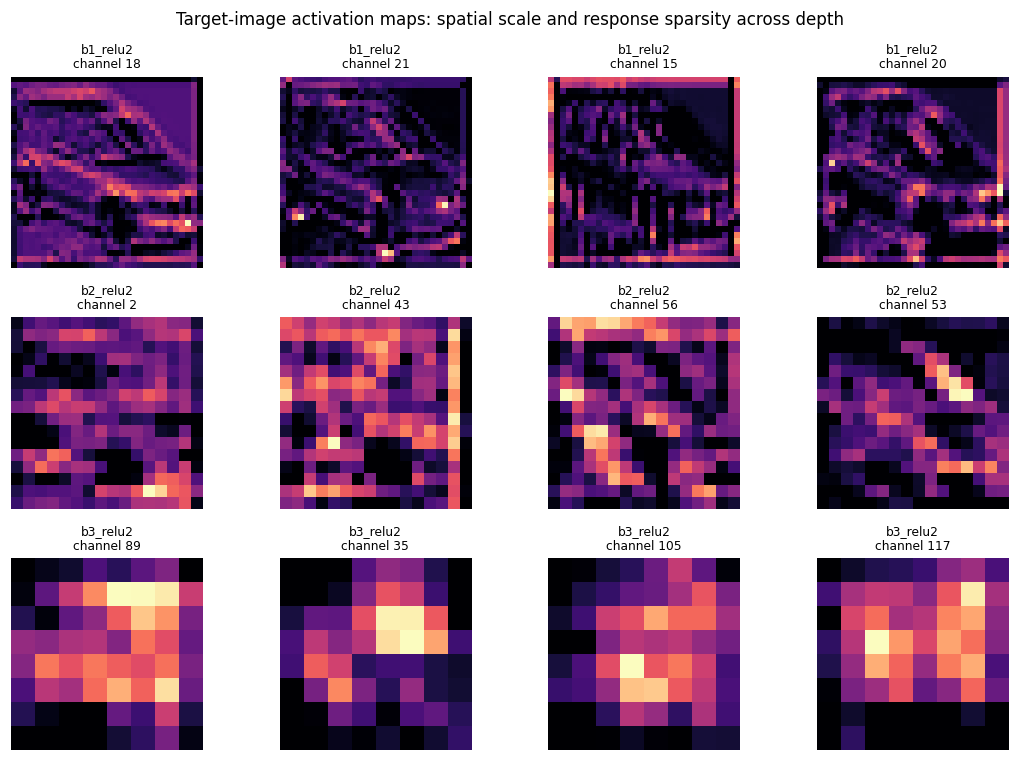

Normalized source/target activation divergence
tap               trained     random     excess
b1_relu2           0.2658     0.1355     0.1303
b2_relu2           0.2212     0.1527     0.0684
b3_relu2           0.1942     0.1667     0.0275

Interpretation: a depth trend shared by trained and random networks can arise from architecture and input-distribution effects. Excess over random shows that source training changed the profile; it does not identify channel semantics or prove specialization.


In [6]:
# --- Representation diagnostics: descriptive maps plus a controlled divergence profile ---
TAP_LAYERS = ["b1_relu2", "b2_relu2", "b3_relu2"]
inspector = keras.Model(
    source_model.input,
    [source_model.get_layer(name).output for name in TAP_LAYERS],
    name="source_representation_inspector",
)

# View 1: activation maps for one target image. These visualize response geometry only.
sample = xt_mon[:1]
feature_maps = inspector.predict(sample, verbose=0)

fig, axes = plt.subplots(len(TAP_LAYERS), 4, figsize=(10, 7))
for row, (layer_name, fmap) in enumerate(zip(TAP_LAYERS, feature_maps)):
    channel_energy = np.mean(np.abs(fmap[0]), axis=(0, 1))
    channels = np.argsort(channel_energy)[-4:][::-1]
    for col, channel in enumerate(channels):
        axes[row, col].imshow(fmap[0, :, :, channel], cmap="magma")
        axes[row, col].axis("off")
        axes[row, col].set_title(f"{layer_name}\nchannel {channel}", fontsize=8)
fig.suptitle(
    "Target-image activation maps: spatial scale and response sparsity across depth",
    fontsize=11,
)
plt.tight_layout()
plt.show()


def divergence_profile(view, source_images, target_images):
    """Normalized source/target mean-activation differences at fixed tap layers."""
    source_maps = view.predict(source_images, verbose=0)
    target_maps = view.predict(target_images, verbose=0)
    profile = {}
    stats = {}
    for name, src_map, tgt_map in zip(TAP_LAYERS, source_maps, target_maps):
        src_mean = np.mean(src_map, axis=(0, 1, 2))
        tgt_mean = np.mean(tgt_map, axis=(0, 1, 2))
        scale = np.linalg.norm(src_mean) + np.linalg.norm(tgt_mean) + 1e-12
        value = float(2.0 * np.linalg.norm(src_mean - tgt_mean) / scale)
        profile[name] = value
        stats[name] = {
            "source_mean_abs": float(np.mean(np.abs(src_mean))),
            "target_mean_abs": float(np.mean(np.abs(tgt_mean))),
        }
    return profile, stats


n_probe = min(500, len(xs_va), len(xt_mon))
trained_profile, trained_activation_stats = divergence_profile(
    inspector, xs_va[:n_probe], xt_mon[:n_probe]
)

# Architecture/depth control: same model structure and inputs, but seeded random weights.
# Re-seeding here is local to this diagnostic; train_variant seeds each training run separately.
keras.utils.set_random_seed(SEED)
random_backbone = build_model(len(ANIMAL_IDS), name="random_divergence_control")
random_inspector = keras.Model(
    random_backbone.input,
    [random_backbone.get_layer(name).output for name in TAP_LAYERS],
    name="random_divergence_inspector",
)
random_profile, random_activation_stats = divergence_profile(
    random_inspector, xs_va[:n_probe], xt_mon[:n_probe]
)

DIVERGENCE = {
    "source_trained": trained_profile,
    "random_init": random_profile,
    "excess_over_random": {
        name: float(trained_profile[name] - random_profile[name])
        for name in TAP_LAYERS
    },
}

print("Normalized source/target activation divergence")
print(f"{'tap':<14} {'trained':>10} {'random':>10} {'excess':>10}")
for name in TAP_LAYERS:
    print(
        f"{name:<14} "
        f"{DIVERGENCE['source_trained'][name]:>10.4f} "
        f"{DIVERGENCE['random_init'][name]:>10.4f} "
        f"{DIVERGENCE['excess_over_random'][name]:>10.4f}"
    )

print(
    "\nInterpretation: a depth trend shared by trained and random networks can arise from "
    "architecture and input-distribution effects. Excess over random shows that source "
    "training changed the profile; it does not identify channel semantics or prove specialization."
)

del random_inspector, random_backbone


---
## Section 4 — Network modification

The **Adaptation** phase of the roadmap begins here, and its first step is structural, not statistical.

The source head is `Dense(6)` — a map from the 128-dimensional pooled feature into the *source* label
space $\mathcal{Y}_s$. The target needs $\mathcal{Y}_t$ with 2 classes. Those spaces have nothing to
do with each other, so the head is **discarded, not adapted**: we build the same backbone with
`Dense(2)` and copy across every weight *except* the head.

This is why Section 1c insisted on naming layers. The transfer is a name-keyed copy:

```
for layer in source.layers:
    if layer.name != "head" and layer.weights:
        target.get_layer(layer.name).set_weights(layer.get_weights())
```

Three properties of doing it this way:

1. **It fails loudly.** A layer that exists in the source and not the target raises rather than being
   silently skipped, and the function returns a count you can assert on.
2. **It survives extra layers.** The LoRA variant in Section 5 has ~18 additional layers that have no
   counterpart in the source. Iterating over the *source* means they are simply left at their
   initialisation, which is exactly what should happen.
3. **It carries BatchNorm statistics.** `get_weights()` on a BN layer returns gamma, beta *and* the
   running mean and variance. Those moving statistics are part of the transferred knowledge and are
   the thing most often lost by ad-hoc copying — and, as Section 8 notes, the thing most often wrong
   when the target domain has shifted.

In [7]:
# Cell 6 — Network modification: same backbone, new head, name-keyed weight transfer.
def transfer_backbone(src, dst, skip=("head",)):
    """Copy every named weight-bearing layer from src into dst, except `skip`.
    Returns (layers_copied, tensors_copied) so the caller can assert instead of trust."""
    n_layers = n_tensors = 0
    for lay in src.layers:
        if not lay.weights or lay.name in skip:
            continue
        tgt = dst.get_layer(lay.name)          # raises ValueError if the name is absent — deliberate
        sw, tw = lay.get_weights(), tgt.get_weights()
        assert len(sw) == len(tw) and all(a.shape == b.shape for a, b in zip(sw, tw)), (
            f"shape mismatch at '{lay.name}': {[a.shape for a in sw]} vs {[b.shape for b in tw]}")
        tgt.set_weights(sw)
        n_layers += 1; n_tensors += len(sw)
    return n_layers, n_tensors


# How many layers SHOULD move? Everything with weights, minus the head.
EXPECTED_TRANSFER = sum(1 for l in source_model.layers if l.weights and l.name != "head")

_demo = build_model(2, name="modified_demo")
_nl, _nt = transfer_backbone(source_model, _demo)
assert _nl == EXPECTED_TRANSFER, f"copied {_nl} layers, expected {EXPECTED_TRANSFER}"
print(f"head replaced: Dense({len(ANIMAL_IDS)}) -> Dense({len(TARGET_IDS)})")
print(f"transferred {_nl} layers / {_nt} weight tensors (every weight-bearing layer except the head)")
print(f"head weights are freshly initialised: "
      f"{[w.shape for w in _demo.get_layer('head').get_weights()]}")

# it also works into the LoRA variant, whose extra layers have no source counterpart
_demo_lora = build_model(2, lora_rank=LORA_RANK, name="modified_demo_lora")
_nl2, _ = transfer_backbone(source_model, _demo_lora)
assert _nl2 == EXPECTED_TRANSFER, f"LoRA variant copied {_nl2}, expected {EXPECTED_TRANSFER}"
print(f"same copy into the LoRA model: {_nl2} layers moved, "
      f"{len(_demo_lora.layers) - len(_demo.layers)} adapter layers left at initialisation")
del _demo, _demo_lora

head replaced: Dense(6) -> Dense(2)
transferred 12 layers / 30 weight tensors (every weight-bearing layer except the head)
head weights are freshly initialised: [(128, 2), (2,)]
same copy into the LoRA model: 12 layers moved, 18 adapter layers left at initialisation


---
## Section 5 — Freeze vs. fine-tune vs. PEFT

One backbone, four ways to adapt it. The roadmap orders them by how much of the network moves; the
practical ordering is by **how many parameters you are asking 400 images to estimate**.

| Strategy | What trains | Roadmap term | Use when |
|---|---|---|---|
| `frozen` | the head only | *Freeze pre-trained layers* | very small target set — the default |
| `unfreeze_b3` | head + last block | *Controlled exception* | moderate domain gap, or class imbalance |
| `lora` | head + low-rank paths + BN adaptation | *PEFT + normalization adaptation* | adapters alter pre-BN activations |
| `scratch` | everything, random init | — | the control that says whether transfer helped at all |

### On the "controlled exception"

The roadmap allows unfreezing the last block for a small target set *if it is deliberate and monitored*.
The choice is the explicit hypothesis from Section 2b: later blocks are more likely to encode
source-task-specific compositions. Section 3 supplies a controlled descriptive diagnostic, not proof
of specialization. Unfreezing block 3 tests that hypothesis; the paired result on disjoint final
evaluation data decides whether the intervention helped. **The diagnostic to report is the balanced-accuracy generalisation gap**: macro-average class recall
on the raw training images minus the same metric on final evaluation. Using balanced accuracy on both
sides prevents the 80/20 training prior from masquerading as overfitting. With only 80 minority
training images, a large positive gap remains a warning that target adaptation did not generalise.

### On PEFT / LoRA, and one thing the usual implementation gets wrong

A LoRA adapter adds a low-rank path beside a frozen weight: $h = Wx + BAx$, where $A$ projects down to
rank $r$ and $B$ projects back up. $B$ is **initialised to zero**, so at step 0 the adapter contributes
nothing and the model is exactly the pre-trained model. Training moves $A$ and $B$ while $W$ remains
frozen. Because this implementation adds the adapter before BatchNorm, the LoRA strategy also adapts
BatchNorm affine parameters and moving statistics; otherwise learned adapter outputs would be normalized
with statistics estimated for the unadapted convolution. The result is reported explicitly as LoRA+BN.

For convolutions, $A$ is an $r$-channel conv with the *same kernel, stride and padding* as $W$, and $B$
is a $1\times1$ conv back to the original width. Because $A$ inherits the geometry of $W$, the two
paths produce identical spatial shapes automatically — **including when the stride is greater than 1**.
Implementations that inject an adapter with a fixed `stride=1` hit a shape mismatch on strided convs
and then "fix" it by skipping those layers. That restriction is a bug being described as a design
choice, and it silently removes the adapter from precisely the layers that reshape the representation.
Copy the geometry, and the problem does not exist. There is no stride special-case in this notebook.

### Freezing and BatchNorm — the trap

In Keras, setting `layer.trainable = False` on a `BatchNormalization` layer does *two* things: it stops
gamma/beta updating, **and** it runs the layer in inference mode so the moving mean/variance stay at
the source values. That is what you want when freezing (the alternative silently rewrites the
transferred statistics using 400 target images), but it also means a frozen backbone normalises target
images with *source-domain* statistics. Section 8 returns to this — it is the single cheapest thing to
fix if transfer underperforms.

`LoRA+BN` is the controlled exception: its adapters change the tensor immediately upstream of BN, so BN
must track the adapted distribution. Base convolution kernels remain frozen, and the table reports the
additional BN parameters rather than presenting the branch as pure adapter-only LoRA.

In [8]:
# Cell 7 — Trainability policies, applied by layer name.
def apply_policy(model, policy):
    """Set `trainable` on every layer according to a named policy. Returns the trainable layer names.

    'all'          everything trains (scratch baseline, and full fine-tuning)
    'head'         only the classification head
    'head+b3'      head plus the last convolutional block
    'head+lora+bn' head plus adapters and BatchNorm; pre-trained conv kernels never move
    """
    trainable_names = []
    for lay in model.layers:
        if not lay.weights:
            continue
        if policy == "all":
            flag = True
        elif policy == "head":
            flag = lay.name == "head"
        elif policy == "head+b3":
            flag = lay.name == "head" or lay.name.startswith("b3_")
        elif policy == "head+lora+bn":
            flag = (lay.name == "head" or "_lora_" in lay.name
                    or isinstance(lay, layers.BatchNormalization))
        else:
            raise ValueError(f"unknown policy {policy!r}")
        lay.trainable = flag
        if flag:
            trainable_names.append(lay.name)
    return trainable_names


# Show what each policy actually selects, before anything is trained. This is the cell to read if a
# variant behaves unexpectedly later.
print(f"{'policy':12s} {'trainable params':>17s} {'% of total':>11s}   trainable layers")
_POLICY_DEMO = [("all", None), ("head", None), ("head+b3", None),
                ("head+lora+bn", LORA_RANK)]
for pol, rank in _POLICY_DEMO:
    m = build_model(2, lora_rank=rank, name=f"demo_{pol.replace('+', '_')}")
    names = apply_policy(m, pol)
    tr, tot = count_params(m)
    shown = ", ".join(names[:4]) + (f", +{len(names)-4} more" if len(names) > 4 else "")
    print(f"{pol:12s} {tr:>17,} {100*tr/tot:>10.2f}%   {shown}")
    del m
print("\nNote the LoRA row: a few percent, not the ~0.1% quoted for large language models. The ratio")
print("scales with backbone size — our backbone is 290k parameters, so a rank-4 adapter is relatively")
print("large. The mechanism is identical; the headline percentage is a property of the model, not LoRA.")

# The stride claim from the markdown above, made checkable instead of asserted. With padding="same"
# the output size is ceil(input/stride) for ANY kernel size, so an adapter that copies the base conv's
# stride and padding agrees on shape at every stride. Our own backbone downsamples with pooling and has
# no strided conv, so this is checked directly rather than relied on.
print("\nadapter/base shape agreement across strides:")
for _stride in (1, 2, 3):
    _x = keras.Input((32, 32, 8))
    _base = layers.Conv2D(16, 3, strides=_stride, padding="same", use_bias=False)(_x)
    _adapt = layers.Conv2D(16, 1, use_bias=False)(
        layers.Conv2D(LORA_RANK, 3, strides=_stride, padding="same", use_bias=False)(_x))
    assert _base.shape == _adapt.shape, f"stride {_stride}: {_base.shape} vs {_adapt.shape}"
    print(f"  stride {_stride}: base {tuple(_base.shape[1:])} == adapter {tuple(_adapt.shape[1:])}")

policy        trainable params  % of total   trainable layers
all                    287,714      99.69%   b1_conv1, b1_bn1, b1_conv2, b1_bn2, +9 more
head                       258       0.09%   head
head+b3                221,954      76.90%   b3_conv1, b3_bn1, b3_conv2, b3_bn2, +1 more
head+lora+bn            14,574       4.83%   b1_conv1_lora_down, b1_conv1_lora_up, b1_bn1, b1_conv2_lora_down, +15 more

Note the LoRA row: a few percent, not the ~0.1% quoted for large language models. The ratio
scales with backbone size — our backbone is 290k parameters, so a rank-4 adapter is relatively
large. The mechanism is identical; the headline percentage is a property of the model, not LoRA.

adapter/base shape agreement across strides:
  stride 1: base (32, 32, 16) == adapter (32, 32, 16)
  stride 2: base (16, 16, 16) == adapter (16, 16, 16)
  stride 3: base (11, 11, 16) == adapter (11, 11, 16)


---
## Section 6 — The training loop, with class imbalance handled

One shared fitter is used for all five variants. Inside every repeated trial, each method receives four
learning-rate candidates, the same 20-epoch ceiling, paired seeds and the same checkpoint rule. The
learning-rate ranges differ because a head, a full network and pretrained blocks optimize differently.

**Class imbalance.** The training set is 320 automobile / 80 truck. Left alone, the loss is dominated
by the majority class and the cheapest solution is to always predict `automobile`. We weight each
sample by the inverse frequency of its class:

$$w_c = \frac{N}{K \cdot n_c}$$

giving 0.625 for the majority and 2.5 for the minority, so each *class* contributes equally to the
loss regardless of how many images it has.

Two implementation notes:

- The weights are carried **inside the dataset** as a third tuple element rather than passed as
  `class_weight=`. Same arithmetic, but it works identically for `tf.data` and arrays, and you can
  print the weights and check them.
- **Validation loss is deliberately unweighted.** The training loss is a lever for optimisation; the
  validation loss is a measurement. Weighting the measurement to match the lever would hide whether
  the lever worked.
- A batch of 32 drawn from an 80/20 split will sometimes contain zero minority examples. Sample
  weighting handles that without complaint — the batch simply contributes only majority gradient.
  No custom sampler is needed, and adding one would be a second mechanism doing the same job.

**Monitoring is not measuring.** The fixed balanced 500-image monitor set selects both learning rate and
checkpoint inside each trial. Only the selected candidate predicts the disjoint balanced 1,500-image
final set; unselected candidates never touch it. This keeps optimization inside the repeated procedure
without selecting configurations on reported examples.


**Repeated inference.** The detailed run remains inspectable, but it is not treated as the method. Ten
predeclared trials independently resample source and target training data, retrain the source model, and
rebuild and re-optimize every adaptation strategy with paired seeds. Exact run-level tests and
hierarchical intervals therefore include training, sampling and configuration-selection variability.

In [9]:
# Cell 8 - The one training loop every variant uses.
_counts = np.bincount(yt_tr, minlength=len(TARGET_IDS))
CLASS_W = {c: len(yt_tr) / (len(TARGET_IDS) * n) for c, n in enumerate(_counts)}
SAMPLE_W = np.array([CLASS_W[c] for c in yt_tr], dtype="float32")
print(f"class counts {dict(zip(TGT_CLASSES, _counts))}")
print(f"sample weights {({k: round(v, 3) for k, v in CLASS_W.items()})}  "
      f"-> weighted mass per class: {[round(float(SAMPLE_W[yt_tr == c].sum()), 1) for c in (0, 1)]}")


def train_variant(tag, policy, lora_rank=None, from_source=True, epochs=TGT_EPOCHS):
    """Train one strategy, reload its best monitor checkpoint, and return those exact weights."""
    keras.utils.set_random_seed(SEED)
    model = build_model(len(TARGET_IDS), lora_rank=lora_rank, name=tag)

    copied = 0
    if from_source:
        copied, _ = transfer_backbone(source_model, model)
        assert copied == EXPECTED_TRANSFER, f"{tag}: copied {copied}, expected {EXPECTED_TRANSFER}"

    apply_policy(model, policy)
    trainable, total = count_params(model)
    model.compile(optimizer=keras.optimizers.Adam(LR),
                  loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
                  metrics=[keras.metrics.SparseCategoricalAccuracy(name="acc")])

    ckpt = ART / f"nb6_{tag}.keras"
    print(f"\n[{tag}]  policy={policy}  source_weights={'yes' if from_source else 'NO (random init)'}"
          f"  trainable={trainable:,}/{total:,} ({100*trainable/total:.1f}%)")
    t0 = time.time()
    hist = model.fit(
        make_ds(xt_tr, yt_tr, TGT_BATCH, training=True, w=SAMPLE_W),
        validation_data=make_ds(xt_mon, yt_mon, 256, training=False),
        epochs=epochs, verbose=0,
        callbacks=[EpochLine(tag),
                   keras.callbacks.ModelCheckpoint(str(ckpt), monitor="val_acc", mode="max",
                                                   save_best_only=True, verbose=0)],
    )
    seconds = time.time() - t0
    best_idx = int(np.argmax(hist.history["val_acc"]))
    selected_epoch = best_idx + 1

    # Invariant: this is both the saved artifact and the model evaluated below.
    selected_model = keras.models.load_model(str(ckpt), compile=False)
    HISTORY[tag] = {k: [float(v) for v in vs] for k, vs in hist.history.items()}
    RESULTS[tag] = {"policy": policy, "from_source": from_source, "lora_rank": lora_rank,
                    "trainable": trainable, "total": total, "seconds": seconds,
                    "selected_epoch": selected_epoch, "checkpoint": ckpt.name,
                    "train_acc_at_selected_epoch": float(hist.history["acc"][best_idx]),
                    "monitor_acc": float(hist.history["val_acc"][best_idx]),
                    "final_epoch_monitor_acc": float(hist.history["val_acc"][-1])}
    print(f"  -> selected epoch {selected_epoch:02d}/{epochs}: monitor acc "
          f"{RESULTS[tag]['monitor_acc']:.3f}; reloaded {ckpt.name}")
    print(f"     final report uses the disjoint {len(xt_eval)}-image evaluation set")
    return selected_model


class counts {'automobile': np.int64(320), 'truck': np.int64(80)}
sample weights {0: np.float64(0.625), 1: np.float64(2.5)}  -> weighted mass per class: [200.0, 200.0]


---
## Section 6b - Negative control: a frozen random backbone

`random_frozen` uses the same architecture, frozen-backbone policy, optimizer, target split, and
trainable head as `head_only`, but its backbone is left at seeded random initialization. This tests
whether the **complete source-pretrained backbone state** provides useful target information beyond a
random feature map under the same head-training protocol.

The comparison does not isolate convolution kernels. Source training changes convolution kernels,
BatchNorm affine parameters, and BatchNorm moving statistics together. The result therefore estimates
the value of that pretrained bundle; a kernel-focused claim requires the matched-normalization
ablation described after the results.

In [10]:
# Cell 9 — Train all five. Order is deliberate: controls first, so a broken pipeline shows up early.
print("=" * 92)
m_random  = train_variant("random_frozen", policy="head",      from_source=False)   # null control
m_scratch = train_variant("scratch",       policy="all",       from_source=False)   # plan's baseline
m_frozen  = train_variant("frozen",        policy="head",      from_source=True)    # full freeze
m_b3      = train_variant("unfreeze_b3",   policy="head+b3",   from_source=True)    # controlled exception
m_lora    = train_variant("lora",          policy="head+lora+bn", from_source=True,
                          lora_rank=LORA_RANK)                                       # PEFT
print("=" * 92)
print(f"five variants trained in {sum(r['seconds'] for r in RESULTS.values()):.0f}s total")


[random_frozen]  policy=head  source_weights=NO (random init)  trainable=258/288,610 (0.1%)
  random_frozen    ep01  loss 0.693 acc 0.250  |  val_loss 0.693 val_acc 0.500
  random_frozen    ep02  loss 0.693 acc 0.200  |  val_loss 0.693 val_acc 0.500
  random_frozen    ep03  loss 0.693 acc 0.200  |  val_loss 0.693 val_acc 0.500
  random_frozen    ep04  loss 0.693 acc 0.200  |  val_loss 0.693 val_acc 0.500
  random_frozen    ep05  loss 0.693 acc 0.200  |  val_loss 0.693 val_acc 0.500
  random_frozen    ep06  loss 0.693 acc 0.200  |  val_loss 0.693 val_acc 0.500
  random_frozen    ep07  loss 0.693 acc 0.207  |  val_loss 0.693 val_acc 0.500
  random_frozen    ep08  loss 0.693 acc 0.213  |  val_loss 0.693 val_acc 0.500
  -> selected epoch 01/8: monitor acc 0.500; reloaded nb6_random_frozen.keras
     final report uses the disjoint 1500-image evaluation set

[scratch]  policy=all  source_weights=NO (random init)  trainable=287,714/288,610 (99.7%)
  scratch          ep01  loss 0.827 acc 0.55

---
## Section 7 — Evaluation: the comparison, and whether it means anything

Five things get reported for every variant, and the order matters:

1. **Accuracy with a marginal confidence interval.** The Wilson interval describes uncertainty for one
   model on the 1,500-image final evaluation set. It is not used as a test of another model.
2. **Representative-run paired comparisons.** Exact McNemar tests use discordant predictions from the
   detailed run. They remain diagnostic and do not drive the method-level verdict.
3. **Per-class precision and recall.** Under 80/20 training, the interesting failure is the minority
   class collapsing. Division by zero is handled explicitly with `np.divide(..., where=...)`.
4. **The balanced-accuracy generalisation gap**, macro recall on clean training images minus macro
   recall on final evaluation. Matching the metric removes the 80/20-versus-50/50 class-prior confound.
5. **Trainable parameters.** The cost side of every row.
6. **Repeated-training inference.** Ten paired trials resample and retrain both tasks. Exact sign-flip
   tests use trials as the unit; hierarchical intervals resample trials and balanced evaluation examples.

**Two paired questions must remain separate.** `frozen` versus `random_frozen` tests whether source
pretraining improved the frozen representation relative to random frozen features. `frozen` versus
`scratch` tests operational transfer: a significant positive difference is evidence of positive transfer,
while a significant negative difference is evidence of negative transfer. Each conclusion uses its own
Holm-adjusted run-level test; the single-run McNemar results remain descriptive.


**What the random-frozen control identifies.** The source-trained and random backbones differ in
convolution kernels, BatchNorm affine parameters, and BatchNorm moving statistics. The comparison is
therefore evidence about the **complete pretrained backbone**, not convolution kernels alone.

Do **not** copy source BatchNorm statistics behind random convolutions: moving means and variances are
conditional on activations produced by the upstream kernels, so that operation creates a normalization
mismatch rather than removing a confound. A kernel-focused ablation needs matched normalization. For
example, reset BatchNorm affine parameters to common values in both backbones and independently
recalibrate each backbone's moving statistics on the same calibration images, excluded from final
evaluation. Alternatively, repeat the experiment with a normalization design whose state is not learned
from source activations. Report either approach as a separate ablation, not as the null control.

In [11]:
# Cell 10 - Metrics plus paired model comparisons.
from fractions import Fraction
from math import comb


def wilson(k, n, z=1.96):
    """Marginal 95% Wilson interval for one accuracy."""
    if n == 0:
        return (0.0, 0.0)
    p = k / n
    d = 1 + z * z / n
    c = p + z * z / (2 * n)
    m = z * np.sqrt(p * (1 - p) / n + z * z / (4 * n * n))
    return float((c - m) / d), float((c + m) / d)


PREDICTIONS = {}


def evaluate(tag, model):
    logits = model.predict(xt_eval, batch_size=256, verbose=0)
    pred = logits.argmax(axis=1)
    PREDICTIONS[tag] = pred
    k = int(len(TARGET_IDS))
    cm = np.zeros((k, k), dtype=int)
    np.add.at(cm, (yt_eval, pred), 1)

    correct = int(np.trace(cm)); n = int(cm.sum())
    acc = correct / n
    lo, hi = wilson(correct, n)
    col, row = cm.sum(axis=0), cm.sum(axis=1)
    prec = np.divide(np.diag(cm), col, out=np.zeros(k), where=col > 0)
    rec = np.divide(np.diag(cm), row, out=np.zeros(k), where=row > 0)

    # Class-prior-invariant gap: macro recall (balanced accuracy) on both raw datasets.
    train_pred = model.predict(xt_tr, batch_size=256, verbose=0).argmax(1)
    train_acc_clean = float((train_pred == yt_tr).mean())       # retained as a descriptive raw score
    train_rec = np.array([float((train_pred[yt_tr == c] == c).mean()) for c in range(k)])
    train_balanced_acc = float(train_rec.mean())
    eval_balanced_acc = float(rec.mean())
    assert np.isclose(acc, eval_balanced_acc), (
        "evaluation accuracy should equal macro recall on a balanced set")

    RESULTS[tag].update({"acc": acc, "acc_lo": lo, "acc_hi": hi, "cm": cm.tolist(),
                         "precision": prec.tolist(), "recall": rec.tolist(),
                         "train_acc_clean": train_acc_clean, "train_recall": train_rec.tolist(),
                         "train_balanced_acc": train_balanced_acc,
                         "eval_balanced_acc": eval_balanced_acc,
                         "gap": train_balanced_acc - eval_balanced_acc,
                         "never_predicted": [TGT_CLASSES[i] for i in range(k) if col[i] == 0]})
    return RESULTS[tag]


for tag, m in [("random_frozen", m_random), ("scratch", m_scratch), ("frozen", m_frozen),
               ("unfreeze_b3", m_b3), ("lora", m_lora)]:
    evaluate(tag, m)

ORDER = ["random_frozen", "scratch", "frozen", "unfreeze_b3", "lora"]
LABEL = {"random_frozen": "random frozen*", "scratch": "from scratch", "frozen": "full freeze",
         "unfreeze_b3": "unfreeze b3", "lora": f"LoRA+BN r={LORA_RANK}"}

hdr = (f"{'variant':16s} {'trainable':>10s} {'accuracy':>9s} {'95% CI':>15s} "
       f"{'prec auto':>10s} {'rec auto':>9s} {'prec truck':>11s} {'rec truck':>10s} {'bal gap':>8s}")
print("REPRESENTATIVE RUN - diagnostic detail only; primary inference follows in Cell 11")
print(hdr); print("-" * len(hdr))
for t in ORDER:
    r = RESULTS[t]
    print(f"{LABEL[t]:16s} {r['trainable']:>10,} {r['acc']:>9.3f} "
          f"[{r['acc_lo']:.3f},{r['acc_hi']:.3f}] {r['precision'][0]:>10.3f} {r['recall'][0]:>9.3f} "
          f"{r['precision'][1]:>11.3f} {r['recall'][1]:>10.3f} {r['gap']:>8.3f}")
print("\n* random frozen = same architecture and freeze policy, but no source training")
print(f"chance on this balanced final evaluation set = {MAJORITY_RATE:.3f}")
for t in ORDER:
    if RESULTS[t]["never_predicted"]:
        print(f"WARNING  {LABEL[t]}: never predicted {RESULTS[t]['never_predicted']}")


def exact_mcnemar(a, b):
    """Two-sided exact McNemar test on paired correctness, with no SciPy dependency."""
    a_correct = PREDICTIONS[a] == yt_eval
    b_correct = PREDICTIONS[b] == yt_eval
    only_a = int(np.sum(a_correct & ~b_correct))
    only_b = int(np.sum(~a_correct & b_correct))
    discordant = only_a + only_b
    if discordant == 0:
        p = 1.0
    else:
        k = min(only_a, only_b)
        tail_numerator = sum(comb(discordant, i) for i in range(k + 1))
        p = min(1.0, 2.0 * float(Fraction(tail_numerator, 1 << discordant)))
    return only_a, only_b, p


# Holm-adjust all C(5,2)=10 paired tests.
_raw = {}
_counts_by_pair = {}
for i, a in enumerate(ORDER):
    for b in ORDER[i + 1:]:
        key = f"{a}__vs__{b}"
        only_a, only_b, p = exact_mcnemar(a, b)
        _raw[key] = p
        _counts_by_pair[key] = (a, b, only_a, only_b)

_sorted = sorted(_raw, key=_raw.get)
_adjusted = {}
_running = 0.0
_m = len(_sorted)
for rank, key in enumerate(_sorted):
    _running = max(_running, min(1.0, (_m - rank) * _raw[key]))
    _adjusted[key] = _running

PAIR_TESTS = {}
print("\nRepresentative-run paired comparisons: exact McNemar, Holm-adjusted across 10 tests")
print(f"{'pair':35s} {'a-only':>7s} {'b-only':>7s} {'raw p':>10s} {'Holm p':>10s} {'sig':>5s}")
for i, a in enumerate(ORDER):
    for b in ORDER[i + 1:]:
        key = f"{a}__vs__{b}"
        _, _, only_a, only_b = _counts_by_pair[key]
        result = {"a": a, "b": b, "a_only_correct": only_a, "b_only_correct": only_b,
                  "accuracy_difference_a_minus_b": RESULTS[a]["acc"] - RESULTS[b]["acc"],
                  "p_raw": _raw[key], "p_holm": _adjusted[key],
                  "significant_0_05": _adjusted[key] < 0.05}
        PAIR_TESTS[key] = result
        pair_label = f"{LABEL[a]} vs {LABEL[b]}"
        print(f"{pair_label:35s} {only_a:7d} {only_b:7d} {_raw[key]:10.4g} "
              f"{_adjusted[key]:10.4g} {str(result['significant_0_05']):>5s}")


REPRESENTATIVE RUN - diagnostic detail only; primary inference follows in Cell 11
variant           trainable  accuracy          95% CI  prec auto  rec auto  prec truck  rec truck  bal gap
----------------------------------------------------------------------------------------------------------
random frozen*          258     0.500 [0.475,0.525]      0.000     0.000       0.500      1.000    0.000
from scratch        287,714     0.701 [0.678,0.724]      0.728     0.643       0.680      0.760    0.163
full freeze             258     0.620 [0.595,0.644]      0.616     0.636       0.624      0.604    0.035
unfreeze b3         221,954     0.821 [0.800,0.839]      0.803     0.849       0.840      0.792    0.100
LoRA+BN r=4          14,574     0.773 [0.751,0.793]      0.799     0.728       0.750      0.817    0.082

* random frozen = same architecture and freeze policy, but no source training
chance on this balanced final evaluation set = 0.500
WARNING  random frozen*: never predicted ['auto

In [12]:
# Cell 11 - Method-level inference across repeated training and sampling trials.
import gc
import tempfile

VARIABILITY_SEEDS = tuple(SEED + 1000 * i for i in range(1, 11))
TRIAL_SPEC = {
    "random_frozen": {"policy": "head", "from_source": False, "lora_rank": None},
    "scratch": {"policy": "all", "from_source": False, "lora_rank": None},
    "frozen": {"policy": "head", "from_source": True, "lora_rank": None},
    "unfreeze_b3": {"policy": "head+b3", "from_source": True, "lora_rank": None},
    "lora": {"policy": "head+lora+bn", "from_source": True, "lora_rank": LORA_RANK},
}
assert set(TRIAL_SPEC) == set(ORDER)
TRIAL_MAX_EPOCHS = 20
TRIAL_SEARCH_SPACE = {
    "random_frozen": [3e-4, 1e-3, 3e-3, 1e-2],
    "scratch": [1e-4, 3e-4, 1e-3, 3e-3],
    "frozen": [3e-4, 1e-3, 3e-3, 1e-2],
    "unfreeze_b3": [1e-5, 3e-5, 1e-4, 3e-4],
    "lora": [1e-4, 3e-4, 1e-3, 3e-3],
}
assert set(TRIAL_SEARCH_SPACE) == set(ORDER)
assert len({len(v) for v in TRIAL_SEARCH_SPACE.values()}) == 1, (
    "every method must receive the same number of optimization candidates")


def fit_source_trial(seed):
    """Reproduce the original fixed source-training procedure on a fresh sample."""
    trial_rng = np.random.default_rng(seed)
    x_source, y_source = take_per_class(
        SOURCE_CANDIDATE_X, SOURCE_CANDIDATE_Y, ANIMAL_IDS,
        SRC_PER_CLASS, trial_rng)
    keras.utils.set_random_seed(seed)
    model = build_model(len(ANIMAL_IDS), name=f"source_trial_{seed}")
    model.compile(
        optimizer=keras.optimizers.Adam(LR),
        loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
        metrics=[keras.metrics.SparseCategoricalAccuracy(name="acc")],
    )
    history = model.fit(
        make_ds(x_source, y_source, SRC_BATCH, training=True, seed=seed),
        validation_data=make_ds(xs_va, ys_va, SRC_BATCH, training=False, seed=seed),
        epochs=SRC_EPOCHS, verbose=0)
    final_val = float(history.history["val_acc"][-1])
    assert final_val > FLOOR_6, (
        f"source trial {seed} failed the representation floor: {final_val:.3f}")
    return model


def sample_target_trial(seed):
    trial_rng = np.random.default_rng(seed)
    return take_per_class(
        TARGET_CANDIDATE_X, TARGET_CANDIDATE_Y, TARGET_IDS,
        [TGT_MAJOR, TGT_MINOR], trial_rng)


def trial_sample_weights(y):
    counts = np.bincount(y, minlength=len(TARGET_IDS))
    class_weights = len(y) / (len(TARGET_IDS) * counts)
    return class_weights[y].astype("float32")


def tune_and_predict_target_trial(tag, seed, source, x_train, y_train):
    """Apply the same four-candidate optimization budget inside each trial."""
    spec = TRIAL_SPEC[tag]
    sample_weights = trial_sample_weights(y_train)
    candidate_records = []
    with tempfile.TemporaryDirectory() as tmp:
        for candidate_index, learning_rate in enumerate(TRIAL_SEARCH_SPACE[tag]):
            # Resetting the seed pairs initialization and augmentation across candidates.
            keras.utils.set_random_seed(seed)
            model = build_model(
                len(TARGET_IDS), lora_rank=spec["lora_rank"],
                name=f"{tag}_trial_{seed}_candidate_{candidate_index}")
            if spec["from_source"]:
                copied, _ = transfer_backbone(source, model)
                assert copied == EXPECTED_TRANSFER
            apply_policy(model, spec["policy"])
            model.compile(
                optimizer=keras.optimizers.Adam(learning_rate),
                loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
                metrics=[keras.metrics.SparseCategoricalAccuracy(name="acc")],
            )
            checkpoint = Path(tmp) / f"{tag}_{seed}_{candidate_index}.keras"
            history = model.fit(
                make_ds(x_train, y_train, TGT_BATCH, training=True,
                        w=sample_weights, seed=seed),
                validation_data=make_ds(
                    xt_mon, yt_mon, 256, training=False, seed=seed),
                epochs=TRIAL_MAX_EPOCHS, verbose=0,
                callbacks=[keras.callbacks.ModelCheckpoint(
                    str(checkpoint), monitor="val_acc", mode="max",
                    save_best_only=True, verbose=0)],
            )
            best_index = int(np.argmax(history.history["val_acc"]))
            candidate_records.append({
                "candidate": candidate_index, "lr": float(learning_rate),
                "monitor_acc": float(history.history["val_acc"][best_index]),
                "selected_epoch": best_index + 1, "checkpoint": checkpoint,
            })
            del model

        winner = max(candidate_records, key=lambda record: (
            record["monitor_acc"], -record["candidate"]))
        selected = keras.models.load_model(str(winner["checkpoint"]), compile=False)
        prediction = selected.predict(
            xt_eval, batch_size=256, verbose=0).argmax(axis=1)
        selected_config = {
            "lr": winner["lr"], "selected_epoch": winner["selected_epoch"],
            "monitor_acc": winner["monitor_acc"],
        }
    del selected
    return prediction, selected_config


TRIAL_ACCURACY = {tag: [] for tag in ORDER}
TRIAL_CORRECT = {tag: [] for tag in ORDER}
TRIAL_PREDICTIONS = {tag: [] for tag in ORDER}
TRIAL_SELECTED_CONFIGS = {tag: [] for tag in ORDER}
for trial_number, trial_seed in enumerate(VARIABILITY_SEEDS, start=1):
    keras.backend.clear_session()
    trial_source = fit_source_trial(trial_seed)
    x_trial, y_trial = sample_target_trial(trial_seed + 1)
    for tag in ORDER:
        prediction, selected_config = tune_and_predict_target_trial(
            tag, trial_seed + 2, trial_source, x_trial, y_trial)
        correct = prediction == yt_eval
        TRIAL_PREDICTIONS[tag].append(prediction)
        TRIAL_CORRECT[tag].append(correct)
        TRIAL_ACCURACY[tag].append(float(correct.mean()))
        TRIAL_SELECTED_CONFIGS[tag].append(selected_config)
    del trial_source, x_trial, y_trial
    keras.backend.clear_session()
    gc.collect()
    print(f"completed variability trial {trial_number}/{len(VARIABILITY_SEEDS)}")


def exact_paired_sign_flip(differences):
    differences = np.asarray(differences, dtype=float)
    observed = abs(float(differences.mean()))
    n = len(differences)
    extreme = 0
    for mask in range(1 << n):
        signs = np.array([1.0 if mask & (1 << i) else -1.0 for i in range(n)])
        if abs(float(np.mean(signs * differences))) >= observed - 1e-15:
            extreme += 1
    return extreme / (1 << n)


def hierarchical_difference_ci(a, b, draws=10000, seed=SEED):
    delta = (np.asarray(TRIAL_CORRECT[a], dtype=float)
             - np.asarray(TRIAL_CORRECT[b], dtype=float))
    bootstrap_rng = np.random.default_rng(seed)
    class_indices = [np.flatnonzero(yt_eval == c) for c in range(len(TARGET_IDS))]
    samples = np.empty(draws)
    for draw in range(draws):
        runs = bootstrap_rng.integers(0, delta.shape[0], size=delta.shape[0])
        examples = np.concatenate([
            bootstrap_rng.choice(idx, size=len(idx), replace=True)
            for idx in class_indices])
        samples[draw] = delta[runs[:, None], examples[None, :]].mean()
    lo, hi = np.quantile(samples, [0.025, 0.975])
    return float(lo), float(hi)


_trial_raw = {}
for i, a in enumerate(ORDER):
    for b in ORDER[i + 1:]:
        key = f"{a}__vs__{b}"
        differences = (np.asarray(TRIAL_ACCURACY[a])
                       - np.asarray(TRIAL_ACCURACY[b]))
        _trial_raw[key] = {
            "a": a, "b": b,
            "mean_difference_a_minus_b": float(differences.mean()),
            "ci_95": hierarchical_difference_ci(a, b),
            "p_raw": exact_paired_sign_flip(differences),
        }
_trial_sorted = sorted(_trial_raw, key=lambda key: _trial_raw[key]["p_raw"])
_trial_running = 0.0
for rank, key in enumerate(_trial_sorted):
    adjusted = min(1.0, (len(_trial_sorted) - rank) * _trial_raw[key]["p_raw"])
    _trial_running = max(_trial_running, adjusted)
    _trial_raw[key]["p_holm"] = _trial_running
    _trial_raw[key]["significant_0_05"] = _trial_running < 0.05
TRIAL_PAIR_TESTS = _trial_raw


def hierarchical_accuracy_ci(tag, draws=10000, seed=SEED):
    correct = np.asarray(TRIAL_CORRECT[tag], dtype=float)
    bootstrap_rng = np.random.default_rng(seed)
    class_indices = [np.flatnonzero(yt_eval == c) for c in range(len(TARGET_IDS))]
    samples = np.empty(draws)
    for draw in range(draws):
        runs = bootstrap_rng.integers(0, correct.shape[0], size=correct.shape[0])
        examples = np.concatenate([
            bootstrap_rng.choice(idx, size=len(idx), replace=True)
            for idx in class_indices])
        samples[draw] = correct[runs[:, None], examples[None, :]].mean()
    lo, hi = np.quantile(samples, [0.025, 0.975])
    return float(lo), float(hi)


MEAN_TRIAL_ACCURACY = {tag: float(np.mean(TRIAL_ACCURACY[tag])) for tag in ORDER}
TRIAL_ACCURACY_CI = {tag: hierarchical_accuracy_ci(tag) for tag in ORDER}
TRIAL_CONFUSION = {}
TRIAL_MINORITY_RECALL = {}
for tag in ORDER:
    aggregate_cm = np.zeros((len(TARGET_IDS), len(TARGET_IDS)), dtype=int)
    minority_recall = []
    for prediction in TRIAL_PREDICTIONS[tag]:
        np.add.at(aggregate_cm, (yt_eval, prediction), 1)
        minority = yt_eval == 1
        minority_recall.append(float((prediction[minority] == 1).mean()))
    TRIAL_CONFUSION[tag] = aggregate_cm.tolist()
    TRIAL_MINORITY_RECALL[tag] = minority_recall
best_tag = max(ORDER, key=MEAN_TRIAL_ACCURACY.get)
print("\nPRIMARY COMPARISON - nested optimization across repeated training trials")
print(f"{'variant':16s} {'mean acc':>9s} {'hierarchical 95% CI':>24s} "
      f"{'selected LR median [range]':>30s}")
for tag in ORDER:
    lo, hi = TRIAL_ACCURACY_CI[tag]
    selected_lrs = [record['lr'] for record in TRIAL_SELECTED_CONFIGS[tag]]
    lr_summary = (f"{np.median(selected_lrs):.1e} "
                  f"[{min(selected_lrs):.1e},{max(selected_lrs):.1e}]")
    print(f"{LABEL[tag]:16s} {MEAN_TRIAL_ACCURACY[tag]:9.3f} "
          f"[{lo:.3f},{hi:.3f}]{'':>9s} {lr_summary:>30s}")
print(f"point-estimate leader across trials: {LABEL[best_tag]} "
      f"({MEAN_TRIAL_ACCURACY[best_tag]:.3f})")

representation_test = TRIAL_PAIR_TESTS["random_frozen__vs__frozen"]
transfer_test = TRIAL_PAIR_TESTS["scratch__vs__frozen"]
gain_vs_random = -representation_test["mean_difference_a_minus_b"]
gain_vs_scratch = -transfer_test["mean_difference_a_minus_b"]
representation_ci = tuple(-x for x in representation_test["ci_95"][::-1])
transfer_ci = tuple(-x for x in transfer_test["ci_95"][::-1])
print(f"\nmean full freeze - random frozen = {gain_vs_random:+.3f} "
      f"95% CI [{representation_ci[0]:+.3f},{representation_ci[1]:+.3f}] "
      f"Holm p={representation_test['p_holm']:.4g}")
print(f"mean full freeze - scratch       = {gain_vs_scratch:+.3f} "
      f"95% CI [{transfer_ci[0]:+.3f},{transfer_ci[1]:+.3f}] "
      f"Holm p={transfer_test['p_holm']:.4g}")

if representation_test["significant_0_05"]:
    representation_direction = "improved" if gain_vs_random > 0 else "degraded"
    print(f"REPRESENTATION: source pretraining {representation_direction} the "
          "frozen representation across trials.")
else:
    print("REPRESENTATION: no significant difference from random frozen features.")
if transfer_test["significant_0_05"]:
    direction = "positive" if gain_vs_scratch > 0 else "NEGATIVE"
    print(f"VERDICT: paired evidence of {direction} transfer across trials.")
else:
    print("VERDICT: positive or negative transfer was not established across trials.")


completed variability trial 1/10
completed variability trial 2/10
completed variability trial 3/10
completed variability trial 4/10
completed variability trial 5/10
completed variability trial 6/10
completed variability trial 7/10
completed variability trial 8/10
completed variability trial 9/10
completed variability trial 10/10

PRIMARY COMPARISON - nested optimization across repeated training trials
variant           mean acc      hierarchical 95% CI     selected LR median [range]
random frozen*       0.610 [0.588,0.632]               1.0e-02 [3.0e-03,1.0e-02]
from scratch         0.781 [0.755,0.803]               1.0e-03 [3.0e-04,1.0e-03]
full freeze          0.724 [0.706,0.742]               1.0e-02 [1.0e-02,1.0e-02]
unfreeze b3          0.823 [0.808,0.837]               3.0e-04 [3.0e-04,3.0e-04]
LoRA+BN r=4          0.835 [0.821,0.848]               3.0e-03 [1.0e-03,3.0e-03]
point-estimate leader across trials: LoRA+BN r=4 (0.835)

mean full freeze - random frozen = +0.113 95% CI 

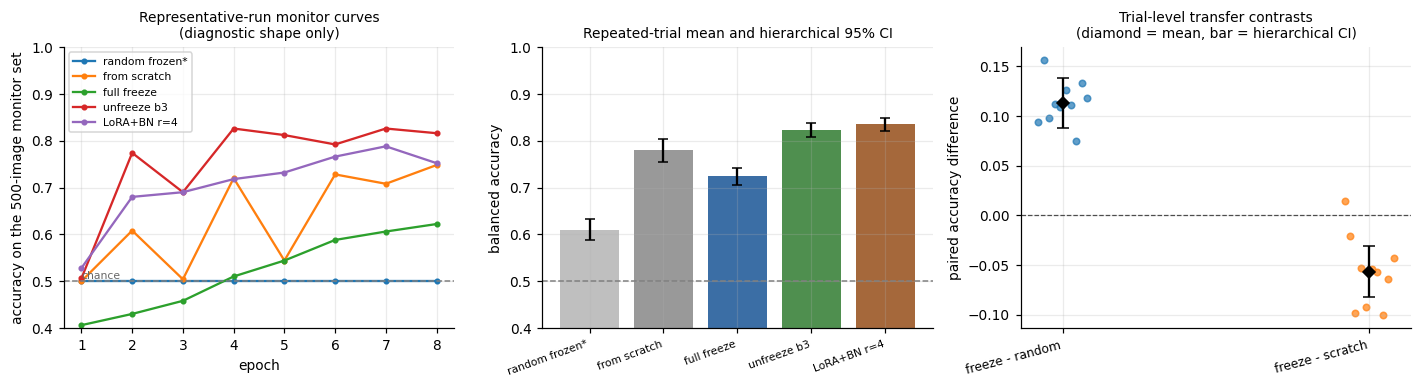

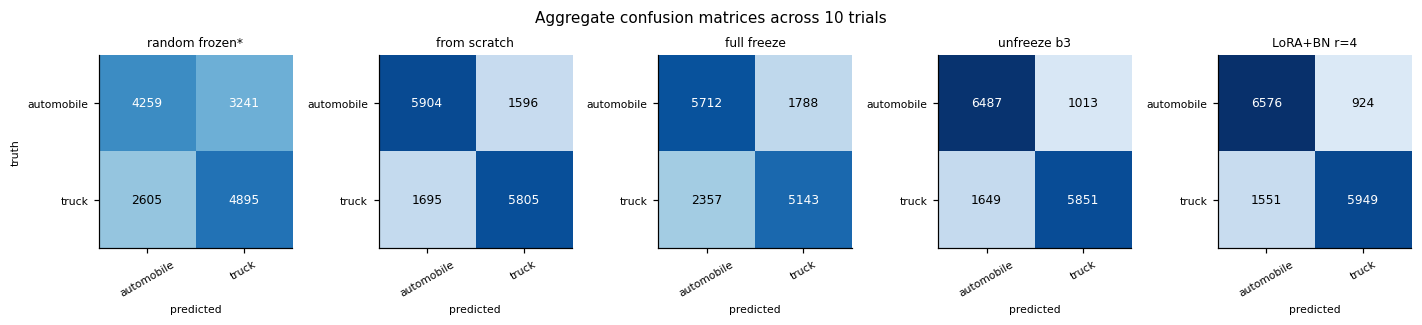

In [13]:
# Cell 12 - Primary repeated-trial figures plus explicitly labeled representative curves.
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))

ax = axes[0]
for t in ORDER:
    ax.plot(range(1, TGT_EPOCHS + 1), HISTORY[t]["val_acc"], marker="o", ms=3, label=LABEL[t])
ax.axhline(MAJORITY_RATE, ls="--", c="0.5", lw=1)
ax.text(1, MAJORITY_RATE + .005, "chance", fontsize=7, color="0.4")
ax.set_xlabel("epoch"); ax.set_ylabel(f"accuracy on the {len(xt_mon)}-image monitor set")
ax.set_ylim(0.4, 1.0)
ax.set_title("Representative-run monitor curves\n(diagnostic shape only)", fontsize=9)
ax.legend(fontsize=7)

ax = axes[1]
xs = np.arange(len(ORDER))
accs = [MEAN_TRIAL_ACCURACY[t] for t in ORDER]
err = np.array([[MEAN_TRIAL_ACCURACY[t] - TRIAL_ACCURACY_CI[t][0] for t in ORDER],
                [TRIAL_ACCURACY_CI[t][1] - MEAN_TRIAL_ACCURACY[t] for t in ORDER]])
ax.bar(xs, accs, yerr=err, capsize=3, color=["0.75", "0.6", "#3b6ea5", "#4f8f4f", "#a5683b"])
ax.axhline(MAJORITY_RATE, ls="--", c="0.5", lw=1)
ax.set_xticks(xs); ax.set_xticklabels([LABEL[t] for t in ORDER], rotation=20, ha="right", fontsize=7)
ax.set_ylabel("balanced accuracy"); ax.set_ylim(0.4, 1.0)
ax.set_title("Repeated-trial mean and hierarchical 95% CI", fontsize=9)

accuracy_ticks = [0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
for accuracy_ax in axes[:2]:
    accuracy_ax.set_yticks(accuracy_ticks)
    accuracy_ax.set_yticklabels([f"{tick:.1f}" for tick in accuracy_ticks])


ax = axes[2]
gain_sets = [
    np.asarray(TRIAL_ACCURACY["frozen"]) - np.asarray(TRIAL_ACCURACY["random_frozen"]),
    np.asarray(TRIAL_ACCURACY["frozen"]) - np.asarray(TRIAL_ACCURACY["scratch"]),
]
gain_cis = [representation_ci, transfer_ci]
gain_labels = ["freeze - random", "freeze - scratch"]
for position, (values, ci) in enumerate(zip(gain_sets, gain_cis)):
    jitter = np.linspace(-0.08, 0.08, len(values))
    ax.scatter(position + jitter, values, s=18, alpha=.7)
    mean = float(values.mean())
    ax.errorbar(position, mean, yerr=[[mean-ci[0]], [ci[1]-mean]],
                fmt="D", c="black", capsize=4, zorder=3)
ax.axhline(0, c="0.3", lw=.8, ls="--")
ax.set_xticks(range(2)); ax.set_xticklabels(gain_labels, rotation=15, ha="right", fontsize=8)
ax.set_ylabel("paired accuracy difference")
ax.set_title("Trial-level transfer contrasts\n(diamond = mean, bar = hierarchical CI)", fontsize=9)

fig.tight_layout(); fig.savefig(ART / "nb6_comparison.png", bbox_inches="tight")
plt.show()

fig, axes = plt.subplots(1, len(ORDER), figsize=(13, 2.8))
aggregate_vmax = max(np.asarray(TRIAL_CONFUSION[t]).max() for t in ORDER)
for ax, t in zip(axes, ORDER):
    cm = np.asarray(TRIAL_CONFUSION[t])
    ax.imshow(cm, cmap="Blues", vmin=0, vmax=aggregate_vmax)
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, f"{cm[i, j]}", ha="center", va="center", fontsize=8,
                    color="white" if cm[i, j] > cm.max() * .6 else "black")
    ax.set_xticks(range(len(TGT_CLASSES))); ax.set_xticklabels(TGT_CLASSES, fontsize=7, rotation=30)
    ax.set_yticks(range(len(TGT_CLASSES))); ax.set_yticklabels(TGT_CLASSES, fontsize=7)
    ax.set_title(LABEL[t], fontsize=8); ax.grid(False)
    ax.set_xlabel("predicted", fontsize=7)
axes[0].set_ylabel("truth", fontsize=7)
fig.suptitle(f"Aggregate confusion matrices across {len(VARIABILITY_SEEDS)} trials", fontsize=10)
fig.tight_layout(); fig.savefig(ART / "nb6_confusion.png", bbox_inches="tight")
plt.show()

---
## Section 8 — Reflection: when does transfer fail?

### Read your own results first

Go back to the prediction you wrote in Section 2b and compare it to the table. Three outcomes, three
different lessons:

- **`frozen` significantly beats `scratch`.** This run provides paired evidence of positive transfer
  for the full-freeze strategy. Read `frozen` versus `random_frozen` separately to determine whether
  source pretraining also improved the frozen representation.
- **`frozen` significantly underperforms `scratch`.** This run provides paired evidence of negative
  transfer: using the source-trained frozen backbone was worse than learning without source knowledge.
- **`frozen` and `scratch` do not differ significantly.** The run did not establish positive or negative
  transfer. A separate difference from `random_frozen` describes representation utility, not superiority
  over target-only learning.

In all three cases the number to quote is the *interval*, not the point estimate.

### Where would this fail badly?

The definition requires $D_s$ and $T_s$ to share structure with $D_t$ and $T_t$. Three targets where
an ImageNet — or animal — backbone would transfer poorly, and *why* differs each time:

| Target | What breaks | Which assumption fails |
|---|---|---|
| **RF spectrograms** | Axes are time and frequency, not space. Translation invariance — the property every conv stack is built on — is wrong along the frequency axis. | Feature transferability: the *inductive bias*, not just the weights, is mismatched |
| **Volumetric CT** | 3D structure projected to 2D slices; intensity is calibrated Hounsfield units, not perceptual RGB | $\mathcal{X}_s \neq \mathcal{X}_t$ — different input space, not merely a different distribution |
| **Document layout** | Discriminative signal is long-range arrangement of near-identical local patches | Task relatedness: the source never needed long-range composition |

The pattern: transfer fails not when the *pictures* look different, but when the **structure the
source model was rewarded for exploiting** is absent from the target. Animals and vehicles look
different and share almost all of their structure. Photographs and spectrograms look similar and share
very little.

### The cheapest thing to try next, and why it is next

If `frozen` underperformed, the first suspect is **BatchNorm statistics, not features**. A frozen
backbone normalises target images using means and variances estimated on the source domain. Recomputing
just those statistics on the target data — training *only* the BN layers, or recomputing the moving
averages with no gradient at all (AdaBN) — costs ~0.2% of parameters and no labels for the AdaBN
version. It is the rung between `frozen` and `unfreeze_b3` on the strategy ladder, and this notebook
deliberately leaves it as the exercise: add a `"head+bn"` branch to `apply_policy`, run
`train_variant("bn_only", policy="head+bn")`, and see where it lands in the table.

**The one rule for climbing that ladder:** go up a rung only while the number keeps improving, and
only while the interval says the improvement is real. Every rung costs labels, compute, or the risk of
destroying what transferred.

In [14]:
# Cell 13 - Final QA and compact run evidence for the submitted notebook.
TOTAL_SECONDS = time.time() - T_START
checks = []


def check(name, ok, detail=""):
    checks.append((name, bool(ok), detail))


def matches_checkpoint(model, checkpoint_name):
    saved = keras.models.load_model(str(ART / checkpoint_name), compile=False)
    same = len(model.weights) == len(saved.weights) and all(
        np.array_equal(a.numpy(), b.numpy()) for a, b in zip(model.weights, saved.weights))
    del saved
    return same


EVALUATED_MODELS = {"random_frozen": m_random, "scratch": m_scratch, "frozen": m_frozen,
                    "unfreeze_b3": m_b3, "lora": m_lora}

check("no downloads", CIFAR_BIN_DIR.exists(), f"only input is {CIFAR_BIN_DIR}")
check("source cleared its derived floor", SRC_VAL_ACC > FLOOR_6,
      f"{SRC_VAL_ACC:.3f} > {FLOOR_6:.3f} (3x chance)")
check("all five variants trained", len(RESULTS) == 5, f"{sorted(RESULTS)}")
check("identical architecture across non-LoRA variants",
      len({r["total"] for r in RESULTS.values() if r["lora_rank"] is None}) == 1,
      "non-LoRA variants share a parameter count")
check("freezing actually froze",
      RESULTS["frozen"]["trainable"] < 0.02 * RESULTS["scratch"]["trainable"],
      f"{RESULTS['frozen']['trainable']:,} vs {RESULTS['scratch']['trainable']:,} params")
check("LoRA is parameter-efficient",
      RESULTS["lora"]["trainable"] < 0.20 * RESULTS["lora"]["total"],
      f"{100*RESULTS['lora']['trainable']/RESULTS['lora']['total']:.1f}% of the model")
check("LoRA BatchNorm tracks adapted activations",
      all(layer.trainable for layer in m_lora.layers
          if isinstance(layer, layers.BatchNormalization)),
      "all BN layers trainable in LoRA+BN")
check("LoRA base convolutions remain frozen",
      all(not layer.trainable for layer in m_lora.layers
          if isinstance(layer, layers.Conv2D) and "_lora_" not in layer.name),
      "base convolution kernels frozen")
check("monitor set is balanced",
      list(np.bincount(yt_mon, minlength=2)) == [TGT_MONITOR_PER_CLASS] * 2,
      f"{np.bincount(yt_mon, minlength=2)}")
check("final evaluation set is balanced",
      list(np.bincount(yt_eval, minlength=2)) == [TGT_EVAL_PER_CLASS] * 2,
      f"{np.bincount(yt_eval, minlength=2)}")
check("monitor and evaluation are disjoint", len(np.intersect1d(_mon, _eval)) == 0,
      f"{len(_mon)} monitor / {len(_eval)} evaluation examples")
check("all 10 paired tests were computed", len(PAIR_TESTS) == 10, f"{len(PAIR_TESTS)} tests")
check("repeated training completed",
      all(len(TRIAL_ACCURACY[tag]) == len(VARIABILITY_SEEDS) for tag in ORDER),
      f"{len(VARIABILITY_SEEDS)} trials per method")
check("equal nested optimization budget",
      len({len(v) for v in TRIAL_SEARCH_SPACE.values()}) == 1,
      f"{len(next(iter(TRIAL_SEARCH_SPACE.values())))} candidates per method")
check("every trial selected a configuration",
      all(len(TRIAL_SELECTED_CONFIGS[tag]) == len(VARIABILITY_SEEDS) for tag in ORDER),
      "one monitor-selected configuration per method and trial")
check("all 10 trial-level paired tests were computed",
      len(TRIAL_PAIR_TESTS) == 10, f"{len(TRIAL_PAIR_TESTS)} tests")
check("primary intervals cover all repeated methods",
      set(TRIAL_ACCURACY_CI) == set(ORDER), f"{sorted(TRIAL_ACCURACY_CI)}")
check("aggregate confusion matrices include every trial prediction",
      all(np.asarray(TRIAL_CONFUSION[tag]).sum() ==
          len(VARIABILITY_SEEDS) * len(yt_eval) for tag in ORDER),
      f"{len(VARIABILITY_SEEDS)} x {len(yt_eval)} predictions per method")
check("generalisation gaps use balanced accuracy",
      all(np.isclose(RESULTS[t]["gap"], RESULTS[t]["train_balanced_acc"] -
                     RESULTS[t]["eval_balanced_acc"]) for t in ORDER),
      "macro recall on train minus macro recall on evaluation")
# 2c. Representation diagnostic includes trained, random, and excess profiles at every tap.
expected_divergence_views = {"source_trained", "random_init", "excess_over_random"}
check(
    "activation divergence has an architecture control",
    set(DIVERGENCE) == expected_divergence_views
    and all(set(DIVERGENCE[name]) == set(TAP_LAYERS) for name in expected_divergence_views),
    "trained, random-init, and excess profiles cover all tap layers",
)

check("evaluated weights equal saved checkpoints",
      all(matches_checkpoint(EVALUATED_MODELS[t], RESULTS[t]["checkpoint"]) for t in ORDER),
      "each table row can be reproduced from its .keras file")
check("every variant beat chance",
      all(RESULTS[t]["acc_lo"] > MAJORITY_RATE for t in ORDER),
      "lower marginal CI bound above chance for all five")
check("null control is present and was not skipped",
      RESULTS["random_frozen"]["from_source"] is False, "random_frozen used no source weights")

width = max(len(c[0]) for c in checks) + 2
print("FINAL QA")
for name, ok, detail in checks:
    print(f"  [{'PASS' if ok else 'FAIL'}] {name:<{width}s} {detail}")

# A control may honestly fail to beat chance; structural/reproducibility failures stop the notebook.
hard_fails = [n for n, ok, _ in checks if not ok and n != "every variant beat chance"]
assert not hard_fails, f"QA failures: {hard_fails}"

print(f"\nruntime: detailed source {SRC_SECONDS:.0f}s; detailed adaptation "
      f"{sum(r['seconds'] for r in RESULTS.values()):.0f}s; full repeated experiment "
      f"{TOTAL_SECONDS:.0f}s total ({TOTAL_SECONDS/60:.1f} min) "
      f"on {'GPU' if _gpus else 'CPU'}")
print("\nINTERPRETATION BOUNDARY:")
print(f"  This run used {6*SRC_PER_CLASS:,} source images for {SRC_EPOCHS} epochs and "
      f"{TGT_EPOCHS} target epochs per variant.")
print("  It demonstrates the experimental structure and controls. Strategy ordering belongs to this")
print("  run and budget; do not assume FAST, FULL, or an ImageNet-scale backbone has the same ranking.")

RUN_CONFIG = {
    "mode": "FAST" if FAST else "FULL",
    "seed": SEED,
    "source_train_images": int(len(xs_tr)),
    "source_epochs": int(SRC_EPOCHS),
    "target_train_images": int(len(xt_tr)),
    "target_epochs": int(TGT_EPOCHS),
    "monitor_images": int(len(xt_mon)),
    "final_evaluation_images": int(len(xt_eval)),
    "variability_seeds": list(VARIABILITY_SEEDS),
    "trial_max_epochs": int(TRIAL_MAX_EPOCHS),
    "optimization_candidates_per_method": int(
        len(next(iter(TRIAL_SEARCH_SPACE.values())))),
}
RUN_EVIDENCE = {
    "status": "executed",
    "config": RUN_CONFIG,
    "source_val_acc": SRC_VAL_ACC,
    "selected_checkpoints": {t: {"file": RESULTS[t]["checkpoint"],
                                      "epoch": RESULTS[t]["selected_epoch"]} for t in ORDER},
    "qa": [{"name": n, "passed": ok, "detail": detail} for n, ok, detail in checks],
    "seconds": TOTAL_SECONDS,
}
RESULT_PAYLOAD = {
    "run_evidence": RUN_EVIDENCE, "results": RESULTS, "history": HISTORY,
    "representative_paired_tests": PAIR_TESTS, "trial_paired_tests": TRIAL_PAIR_TESTS,
    "trial_accuracy": TRIAL_ACCURACY,
    "trial_accuracy_ci": TRIAL_ACCURACY_CI,
    "trial_confusion": TRIAL_CONFUSION,
    "trial_minority_recall": TRIAL_MINORITY_RECALL,
    "trial_selected_configs": TRIAL_SELECTED_CONFIGS,
    "trial_search_space": TRIAL_SEARCH_SPACE, "divergence": DIVERGENCE,
}
(ART / "nb6_results.json").write_text(json.dumps(RESULT_PAYLOAD, indent=2))

print("\nRUN EVIDENCE")
print(json.dumps(RUN_EVIDENCE, indent=2))
print(f"\nwrote {ART / 'nb6_results.json'}")
print("SUBMISSION CHECK: save/export the notebook with this RUN EVIDENCE output visible.")

FINAL QA
  [PASS] no downloads                                                  only input is data/cifar10_raw/cifar-10-batches-bin
  [PASS] source cleared its derived floor                              0.507 > 0.500 (3x chance)
  [PASS] all five variants trained                                     ['frozen', 'lora', 'random_frozen', 'scratch', 'unfreeze_b3']
  [PASS] identical architecture across non-LoRA variants               non-LoRA variants share a parameter count
  [PASS] freezing actually froze                                       258 vs 287,714 params
  [PASS] LoRA is parameter-efficient                                   4.8% of the model
  [PASS] LoRA BatchNorm tracks adapted activations                     all BN layers trainable in LoRA+BN
  [PASS] LoRA base convolutions remain frozen                          base convolution kernels frozen
  [PASS] monitor set is balanced                                       [250 250]
  [PASS] final evaluation set is balanced            